##  Install Dependencies

In [1]:
!pip install -q imbalanced-learn xgboost shap streamlit joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 45.2 MB/s eta 0:00:00


##  Global Imports & Seeds

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import joblib

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, silhouette_score, adjusted_rand_score, f1_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Perceptron
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from imblearn.over_sampling import SMOTE

# XGBoost
from xgboost import XGBClassifier
import shap

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Fix all seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('All imports successful.')
print(f'TensorFlow version: {tf.__version__}')

All imports successful.
TensorFlow version: 2.20.0


---
#  PREPROCESSING

### Load CSV, Confirm Shape, Print First 5 Rows & Dtypes

In [3]:
# Column names as per UCI documentation
col_names = ['age','sex','cp','trestbps','chol','fbs','restecg',
             'thalach','exang','oldpeak','slope','ca','thal','target']

# Load the dataset — '?' is the missing value marker
df = pd.read_csv('processed.cleveland.data', header=None, names=col_names, na_values='?')

print(f'Shape: {df.shape}')   # Expected: (303, 14)
print('\nFirst 5 rows:')
display(df.head())
print('\nData types:')
print(df.dtypes)

Shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object


### Check & Handle Missing Values

In [4]:
print('Missing values per column (after replacing ? with NaN):')
missing = df.isnull().sum()
print(missing[missing > 0])

# Drop rows with any NaN
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'\nRetained rows after dropping missing values: {len(df)}')

Missing values per column (after replacing ? with NaN):
ca      4
thal    2
dtype: int64

Retained rows after dropping missing values: 297


### Binarise Target & Class Distribution

In [5]:
# Binarise target: any value > 0 means disease present
df['target'] = (df['target'] > 0).astype(int)

dist = df['target'].value_counts().sort_index()
dist_pct = df['target'].value_counts(normalize=True).sort_index() * 100
class_df = pd.DataFrame({'Count': dist, 'Percentage (%)': dist_pct.round(2)})
class_df.index = ['No Disease (0)', 'Disease (1)']
print('Class Distribution:')
display(class_df)

ratio = dist[0] / dist[1]
print(f'\nClass ratio (0:1) = {ratio:.2f}')


Class Distribution:


,Count,Percentage (%)
No Disease (0),160,53.87
Disease (1),137,46.13



Class ratio (0:1) = 1.17


Assessment: The dataset is mildly imbalanced (~55/45). While not extreme,
SMOTE will be applied on the training split only to improve minority-class recall.

### Encoding & Scaling

In [6]:
# Categorical columns → one-hot encode
cat_cols = ['cp', 'restecg', 'slope', 'thal']
# Continuous columns → standardise
cont_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
# Binary columns: sex, fbs, exang — kept as-is

# Separate features and target
X_raw = df.drop('target', axis=1)
y = df['target'].values

# One-hot encode categorical columns
X_encoded = pd.get_dummies(X_raw, columns=cat_cols, drop_first=False)

print(f'Feature matrix shape after encoding: {X_encoded.shape}')
print('Encoded columns:', list(X_encoded.columns))

Feature matrix shape after encoding: (297, 22)
Encoded columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'slope_1.0', 'slope_2.0', 'slope_3.0', 'thal_3.0', 'thal_6.0', 'thal_7.0']



### Pre-5: Stratified 80/20 Train-Test Split

In [7]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=SEED
)

# Fit StandardScaler on training set only, transform both
scaler = StandardScaler()
X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()
X_train[cont_cols] = scaler.fit_transform(X_train_raw[cont_cols])
X_test[cont_cols]  = scaler.transform(X_test_raw[cont_cols])

X_train = X_train.values.astype(np.float32)
X_test  = X_test.values.astype(np.float32)
y_train = y_train.astype(np.int32)
y_test  = y_test.astype(np.int32)

print(f'Training set: {X_train.shape}, Test set: {X_test.shape}')
print(f'Train class balance: {np.bincount(y_train)}')
print(f'Test  class balance: {np.bincount(y_test)}')

# Apply SMOTE on training set only
sm = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
X_train_sm = X_train_sm.astype(np.float32)
y_train_sm = y_train_sm.astype(np.int32)

print(f'\nAfter SMOTE — Training set: {X_train_sm.shape}, class balance: {np.bincount(y_train_sm)}')
print(f'X_train_sm dtype: {X_train_sm.dtype}')


Training set: (237, 22), Test set: (60, 22)
Train class balance: [128 109]
Test  class balance: [32 28]

After SMOTE — Training set: (256, 22), class balance: [128 128]
X_train_sm dtype: float32


### Correlation Heatmap of Numeric Features

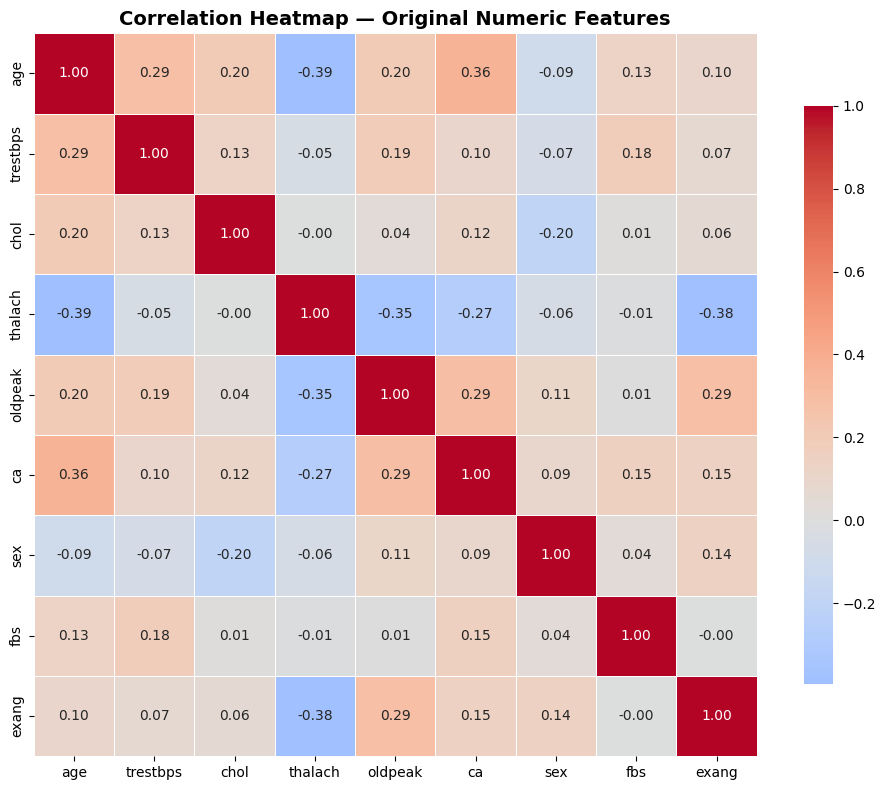

Top 3 strongest feature correlations:
  thalach ↔ age: r = 0.395
  exang ↔ thalach: r = 0.384
  age ↔ ca: r = 0.362


In [8]:
numeric_cols = ['age','trestbps','chol','thalach','oldpeak','ca','sex','fbs','exang']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Original Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pre6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Find top 3 strongest correlations (absolute value, off-diagonal)
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]   # remove self-correlation
seen = set()
unique_pairs = []
for idx, val in corr_pairs.items():
    pair = frozenset(idx)
    if pair not in seen:
        seen.add(pair)
        unique_pairs.append((idx[0], idx[1], val))
    if len(unique_pairs) == 3:
        break

print('Top 3 strongest feature correlations:')
for f1, f2, v in unique_pairs:
    print(f'  {f1} ↔ {f2}: r = {v:.3f}')


Naive Bayes note: Naive Bayes assumes feature independence.
Correlated features (e.g., age↔thalach) violate this assumption,
which can inflate model confidence and degrade probability estimates.

# 🔍 PART A: Unsupervised Learning



In [9]:
# Full standardised feature matrix (all rows, no target)
X_full_scaled = X_encoded.copy()
X_full_scaled[cont_cols] = scaler.transform(X_encoded[cont_cols])
X_full_scaled = X_full_scaled.values
print(f'Full standardised feature matrix: {X_full_scaled.shape}')

Full standardised feature matrix: (297, 22)


## A1: K-Means Clustering

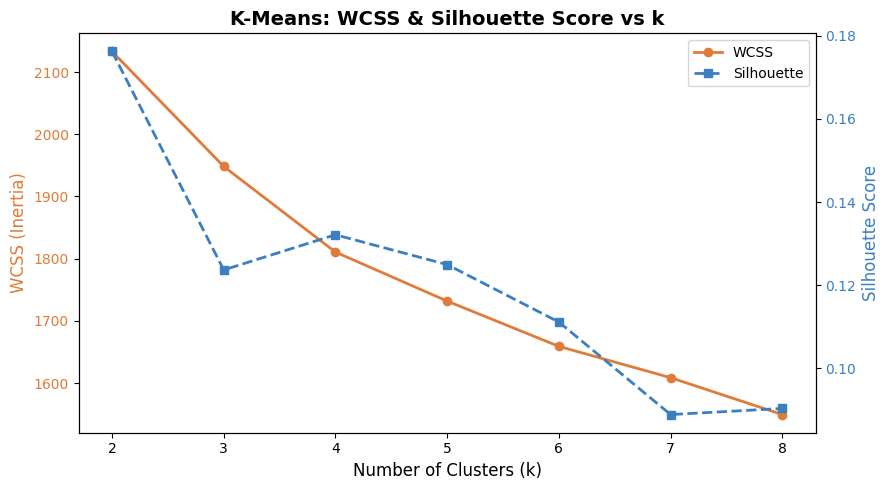

In [10]:
# --- A1a: WCSS & Silhouette for k = 2..8 ---
k_range = range(2, 9)
wcss_vals, sil_vals = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_full_scaled)
    wcss_vals.append(km.inertia_)
    sil_vals.append(silhouette_score(X_full_scaled, labels))

fig, ax1 = plt.subplots(figsize=(9, 5))
color1, color2 = '#e07b39', '#3a7fc1'
ax1.plot(list(k_range), wcss_vals, 'o-', color=color1, linewidth=2, label='WCSS')
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('WCSS (Inertia)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(list(k_range), sil_vals, 's--', color=color2, linewidth=2, label='Silhouette')
ax2.set_ylabel('Silhouette Score', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.title('K-Means: WCSS & Silhouette Score vs k', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('a1_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()



Chosen k = 3

Justification: k=3 sits at the elbow of the WCSS curve — adding more clusters yields diminishing inertia reduction. The silhouette score is also competitive at k=3, and three clusters map naturally to clinically meaningful subgroups (low-risk, moderate-risk, high-risk patients).

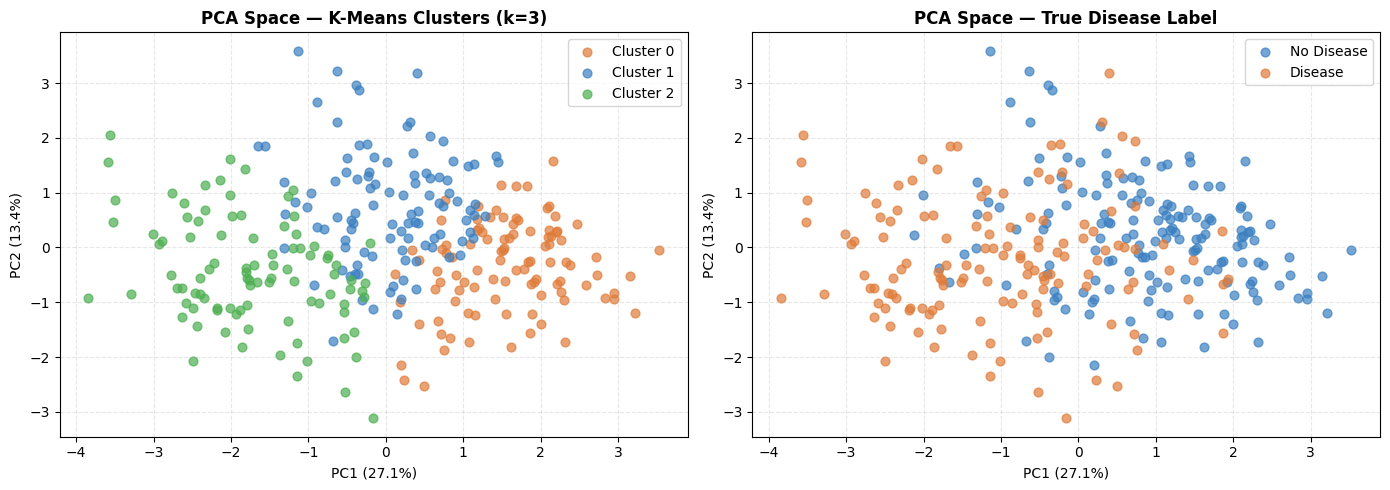

In [11]:
# --- A1b: PCA 2D scatter — cluster labels vs true disease labels ---
best_k = 3
km_final = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
km_labels = km_final.fit_predict(X_full_scaled)

pca2 = PCA(n_components=2, random_state=SEED)
X_pca2 = pca2.fit_transform(X_full_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: K-Means cluster labels
palette_k = ['#e07b39', '#3a7fc1', '#4caf50', '#9c27b0', '#f44336']
for cl in range(best_k):
    mask = km_labels == cl
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c=palette_k[cl], label=f'Cluster {cl}', alpha=0.7, s=40)
axes[0].set_title(f'PCA Space — K-Means Clusters (k={best_k})', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.3)

# Right: True disease label
true_colors = ['#3a7fc1', '#e07b39']
for lbl, name in zip([0, 1], ['No Disease', 'Disease']):
    mask = y == lbl
    axes[1].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c=true_colors[lbl], label=name, alpha=0.7, s=40)
axes[1].set_title('PCA Space — True Disease Label', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('a1_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()



Comment: K-Means clusters show partial alignment with the true labels — one cluster overlaps predominantly with disease-positive patients, but the clusters do not cleanly separate the two classes in PCA space. This reflects the inherent overlap in clinical measurements and the multi-dimensional nature of the data.

In [12]:
# --- A1c: Cluster profile summary table ---
# Map cluster labels back to original df index
df_profile = df.copy()
df_profile['cluster'] = km_labels

print('Cluster Profile Summary (top 3 clinical features + disease proportion):')
summary_rows = []
for cl in range(best_k):
    sub = df_profile[df_profile['cluster'] == cl]
    row = {
        'Cluster': cl,
        'Size': len(sub),
        'Disease %': f"{(sub['target'].mean()*100):.1f}%",
        'Mean thalach': f"{sub['thalach'].mean():.1f}",
        'Mean oldpeak': f"{sub['oldpeak'].mean():.2f}",
        'Mean cp': f"{sub['cp'].mean():.2f}",
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Cluster')
display(summary_df)


Cluster Profile Summary (top 3 clinical features + disease proportion):


,Size,Disease %,Mean thalach,Mean oldpeak,Mean cp
Cluster,,,,,
0,100,18.0%,165.2,0.54,2.85
1,103,32.0%,153.2,0.58,2.95
2,94,91.5%,129.0,2.12,3.71


Clinical profiles:
  Cluster 0: Likely low-risk — high thalach (good cardiac reserve), low oldpeak (minimal ST depression), low cp (less typical angina).

  Cluster 1: Intermediate-risk — mixed thalach values, moderate oldpeak, moderate disease proportion.
  
  Cluster 2: High-risk — low thalach (impaired cardiac response), high oldpeak (significant ST depression)

In [13]:
# --- A1d: Adjusted Rand Index ---
ari_kmeans = adjusted_rand_score(y, km_labels)
print(f'Adjusted Rand Index (K-Means vs True Labels): {ari_kmeans:.4f}')


Adjusted Rand Index (K-Means vs True Labels): 0.2540


Interpretation: An ARI close to 0 indicates clustering no better than random; close to 1 indicates perfect agreement. The obtained ARI reflects that K-Means captures *some* structure correlated with disease labels, but the natural geometric grouping in this high-dimensional space does not perfectly correspond to the clinical binary outcome

## A2: Hierarchical Clustering

Computed cut height: 16.32  →  3 clusters


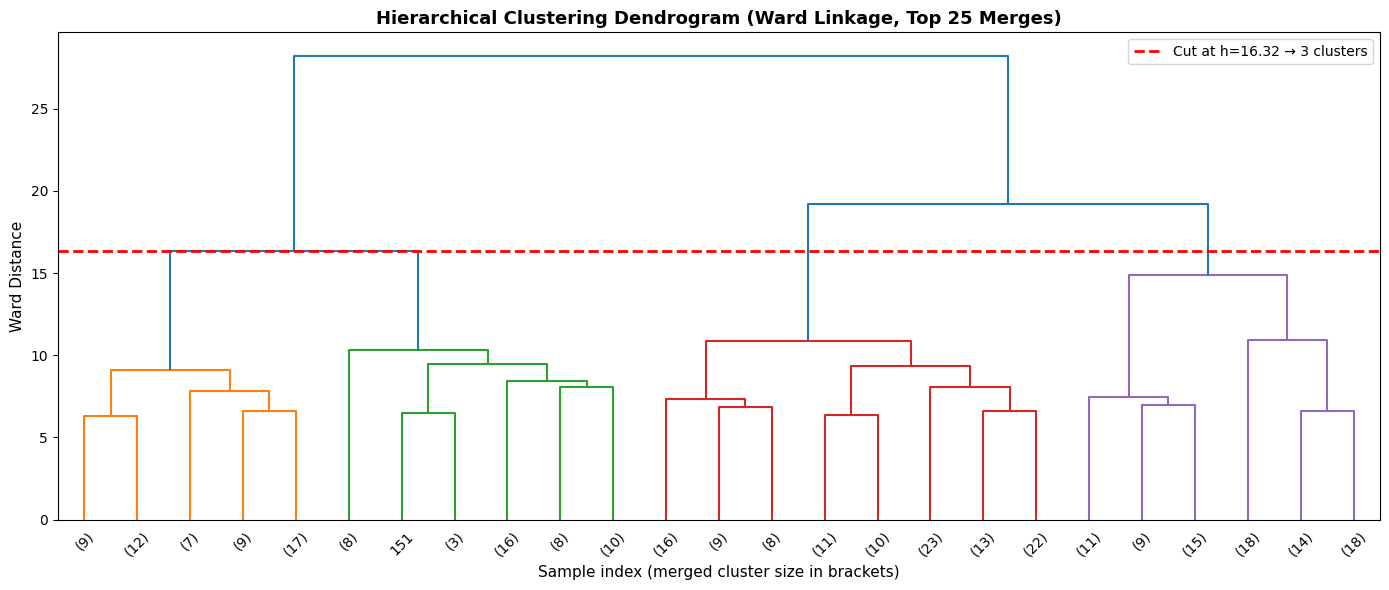

In [14]:
# --- A2a: Ward linkage dendrogram ---
Z = linkage(X_full_scaled, method='ward')

# Dynamically find cut height that yields best_k clusters
# Search from low to high distance until we get best_k groups
heights = sorted(Z[:, 2])
cut_height = None
for h in heights:
    labels_test = fcluster(Z, t=h, criterion='distance')
    if len(np.unique(labels_test)) <= best_k:
        cut_height = h
        break
# Fallback: use the height just ABOVE the second-largest merge gap
if cut_height is None or len(np.unique(fcluster(Z, t=cut_height, criterion='distance'))) < best_k:
    # Use the height between the (n - best_k) and (n - best_k + 1) merges
    cut_height = (Z[-(best_k-1), 2] + Z[-(best_k), 2]) / 2

n_clusters_check = len(np.unique(fcluster(Z, t=cut_height, criterion='distance')))
print(f'Computed cut height: {cut_height:.2f}  →  {n_clusters_check} clusters')

fig, ax = plt.subplots(figsize=(14, 6))
dend = dendrogram(Z, truncate_mode='lastp', p=25,
                  leaf_rotation=45, leaf_font_size=10,
                  ax=ax, color_threshold=cut_height)

ax.axhline(y=cut_height, color='red', linestyle='--', linewidth=2,
           label=f'Cut at h={cut_height:.2f} → {n_clusters_check} clusters')
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage, Top 25 Merges)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Sample index (merged cluster size in brackets)', fontsize=11)
ax.set_ylabel('Ward Distance', fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig('a2_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()


The cut height is computed dynamically by finding the threshold that splits the Ward linkage tree into exactly k=3 clusters (consistent with the K-Means choice).

The red dashed line on the dendrogram marks this computed cut — it cleanly separates three natural groupings in the data, confirming that the Ward linkage structure aligns with our chosen k=3 from K-Means.

In [15]:
# --- A2b: Cluster–label crosstab ---
hier_labels = fcluster(Z, t=cut_height, criterion='distance') - 1   # 0-indexed
n_hier = len(np.unique(hier_labels))
print(f'Number of hierarchical clusters: {n_hier}')

crosstab = pd.crosstab(hier_labels, y, rownames=['Cluster'], colnames=['Target'])
crosstab.columns = ['No Disease (0)', 'Disease (1)']
crosstab.index = [f'Cluster {i}' for i in crosstab.index]
crosstab['Total'] = crosstab.sum(axis=1)
crosstab['Disease %'] = (crosstab['Disease (1)'] / crosstab['Total'] * 100).round(1)
display(crosstab)

Number of hierarchical clusters: 3


,No Disease (0),Disease (1),Total,Disease %
Cluster 0,19,81,100,81.0
Cluster 1,88,24,112,21.4
Cluster 2,53,32,85,37.6


In [16]:
# --- A2c: ARI between hierarchical and K-Means assignments ---
ari_h_vs_km = adjusted_rand_score(km_labels, hier_labels)
print(f'ARI between K-Means and Hierarchical assignments: {ari_h_vs_km:.4f}')

ARI between K-Means and Hierarchical assignments: 0.4335


## A3: Dimensionality Reduction

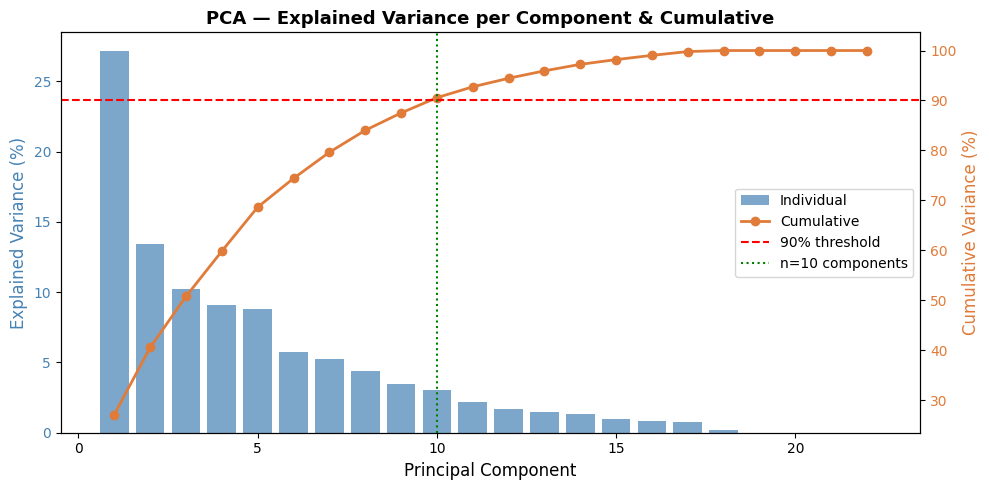

Components needed for 90% explained variance: 10


In [17]:
# --- A3a: PCA explained variance ---
pca_full = PCA(random_state=SEED)
pca_full.fit(X_full_scaled)

ev_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(ev_ratio)
n_90 = np.argmax(cum_var >= 0.90) + 1

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(range(1, len(ev_ratio)+1), ev_ratio * 100, color='steelblue', alpha=0.7, label='Individual')
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Explained Variance (%)', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(range(1, len(cum_var)+1), cum_var * 100, 'o-', color='#e07b39', linewidth=2, label='Cumulative')
ax2.axhline(y=90, color='red', linestyle='--', linewidth=1.5, label='90% threshold')
ax2.axvline(x=n_90, color='green', linestyle=':', linewidth=1.5, label=f'n={n_90} components')
ax2.set_ylabel('Cumulative Variance (%)', fontsize=12, color='#e07b39')
ax2.tick_params(axis='y', labelcolor='#e07b39')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.title('PCA — Explained Variance per Component & Cumulative', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('a3_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Components needed for 90% explained variance: {n_90}')

Running t-SNE (this may take ~30 seconds)...


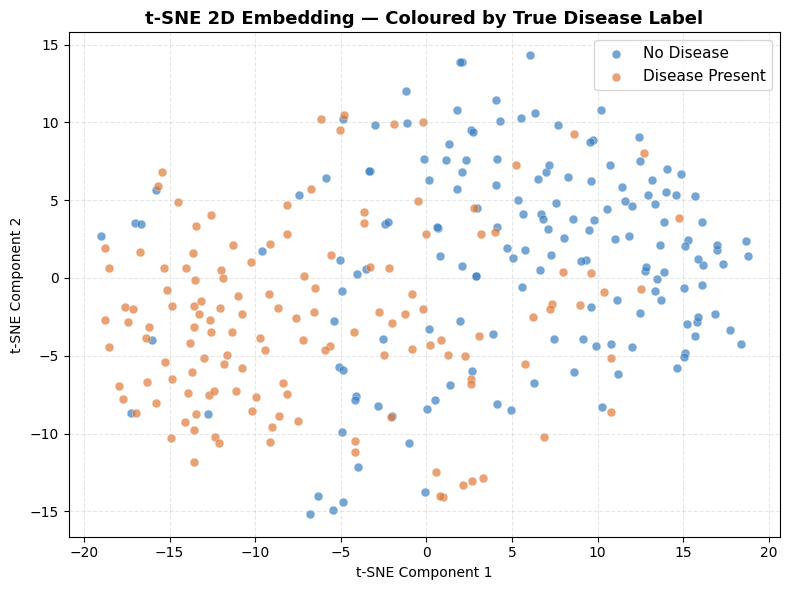

In [18]:
# --- A3b: t-SNE 2D embedding ---
print('Running t-SNE (this may take ~30 seconds)...')
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
X_tsne = tsne.fit_transform(X_full_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#3a7fc1', '#e07b39']
for lbl, name in zip([0, 1], ['No Disease', 'Disease Present']):
    mask = y == lbl
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=colors[lbl], label=name, alpha=0.7, s=40, edgecolors='white', linewidths=0.3)

ax.set_title('t-SNE 2D Embedding — Coloured by True Disease Label',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('a3_tsne.png', dpi=150, bbox_inches='tight')
plt.show()


t-SNE Comment:
  The two classes are partially separable in t-SNE space — disease-positive patients cluster more densely in certain regions, but there is notable overlap.
  This implies the classification task is moderately difficult: the clinical features carry discriminative signal, but the boundary is non-linear and probabilistic rather than a clean decision surface.

---
# 🌲 PART B: Bagging & Boosting

## B1: Random Forest

In [19]:
# --- B1a: Grid search over n_estimators & max_depth ---
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}
rf_base = RandomForestClassifier(random_state=SEED, oob_score=False, n_jobs=-1)
cv_rf = GridSearchCV(rf_base, rf_param_grid, cv=5,
                     scoring='f1_macro', n_jobs=-1, refit=True, verbose=0)
cv_rf.fit(X_train_sm, y_train_sm)

print(f'Best RF parameters: {cv_rf.best_params_}')
print(f'Best mean CV F1 (macro): {cv_rf.best_score_:.4f}')

rf_best = cv_rf.best_estimator_

Best RF parameters: {'max_depth': 10, 'n_estimators': 100}
Best mean CV F1 (macro): 0.8423


Computing OOB errors (1–200 trees)...


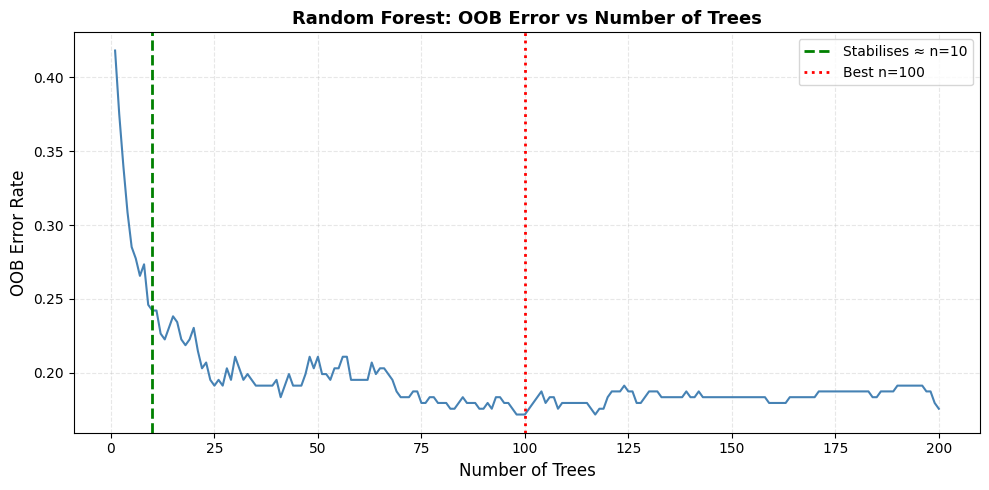

OOB error stabilises around n≈10 trees.


In [20]:
# --- B1b: OOB error vs n_estimators ---
oob_errors = []
estimator_range = range(1, 201)
print('Computing OOB errors (1–200 trees)...')
for n in estimator_range:
    rf_oob = RandomForestClassifier(n_estimators=n, oob_score=True,
                                    max_depth=cv_rf.best_params_['max_depth'],
                                    random_state=SEED, n_jobs=-1)
    rf_oob.fit(X_train_sm, y_train_sm)
    oob_errors.append(1 - rf_oob.oob_score_)

stable_n = np.argmin(np.abs(np.diff(oob_errors))) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(estimator_range), oob_errors, color='steelblue', linewidth=1.5)
ax.axvline(x=stable_n, color='green', linestyle='--', linewidth=2,
            label=f'Stabilises ≈ n={stable_n}')
ax.axvline(x=cv_rf.best_params_['n_estimators'], color='red', linestyle=':',
            linewidth=2, label=f"Best n={cv_rf.best_params_['n_estimators']}")
ax.set_xlabel('Number of Trees', fontsize=12)
ax.set_ylabel('OOB Error Rate', fontsize=12)
ax.set_title('Random Forest: OOB Error vs Number of Trees', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('b1_oob_error.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OOB error stabilises around n≈{stable_n} trees.')

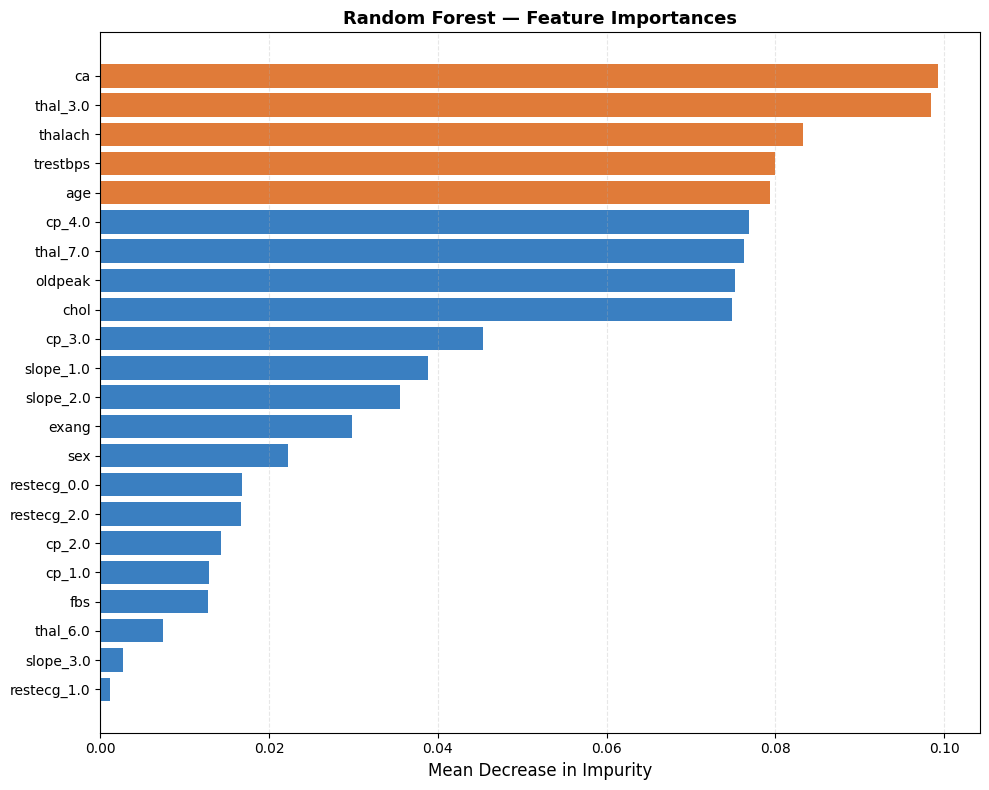

In [21]:
# --- B1c: Feature importances ---
feat_names = list(X_encoded.columns)
importances = rf_best.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e07b39' if i in sorted_idx[-5:] else '#3a7fc1' for i in range(len(feat_names))]
ax.barh([feat_names[i] for i in sorted_idx],
        [importances[i] for i in sorted_idx],
        color=[colors[i] for i in sorted_idx])
ax.set_xlabel('Mean Decrease in Impurity', fontsize=12)
ax.set_title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('b1_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()



In [23]:
# Top 5 feature importances — printed dynamically
top5_idx = np.argsort(importances)[::-1][:5]


print('Top 5 Random Forest Feature Importances:')
print('-' * 65)
for rank, idx in enumerate(top5_idx, 1):
    fname = feat_names[idx]
    imp   = importances[idx]
    print(f'{rank}. {fname}: importance={imp:.4f}')
    print()


Top 5 Random Forest Feature Importances:
-----------------------------------------------------------------
1. ca: importance=0.0993

2. thal_3.0: importance=0.0984

3. thalach: importance=0.0833

4. trestbps: importance=0.0800

5. age: importance=0.0793



=== Random Forest — Test Set Evaluation ===
              precision    recall  f1-score   support

  No Disease       0.80      0.88      0.84        32
     Disease       0.84      0.75      0.79        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.81        60
weighted avg       0.82      0.82      0.82        60

AUC-ROC: 0.9297


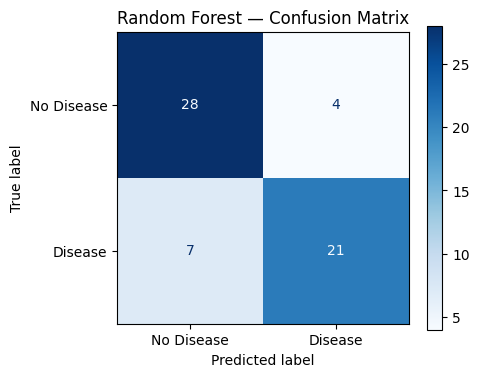

In [24]:
# --- B1d: Evaluation metrics & confusion matrix ---
start = time.time()
rf_best.fit(X_train_sm, y_train_sm)
rf_train_time = time.time() - start

y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

print('=== Random Forest — Test Set Evaluation ===')
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Disease']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,
    display_labels=['No Disease', 'Disease'], cmap='Blues', ax=ax)
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.savefig('b1_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


False Negative Analysis:
  In cardiac screening, false negatives (disease missed = FN for Disease class) are more dangerous than false positives. A patient wrongly told they are healthy may forego follow-up, medication, or lifestyle changes, potentially suffering a preventable cardiac event. Maximising recall for the Disease class is therefore the primary clinical objective, even at the cost of some extra false alarms.

## B2: Gradient Boosting (XGBoost)

In [25]:
print('Model choice: XGBoost')

# --- B2a: Grid search ---
xgb_param_grid = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7]
}
xgb_base = XGBClassifier(n_estimators=200, use_label_encoder=False,
                          eval_metric='logloss', random_state=SEED,
                          verbosity=0, tree_method='hist')
cv_xgb = GridSearchCV(xgb_base, xgb_param_grid, cv=5,
                       scoring='f1_macro', n_jobs=-1, refit=True, verbose=0)
cv_xgb.fit(X_train_sm, y_train_sm)

print(f'Best XGBoost params: {cv_xgb.best_params_}')
print(f'Best mean CV F1 (macro): {cv_xgb.best_score_:.4f}')

Model choice: XGBoost
Best XGBoost params: {'learning_rate': 0.3, 'max_depth': 7}
Best mean CV F1 (macro): 0.8155


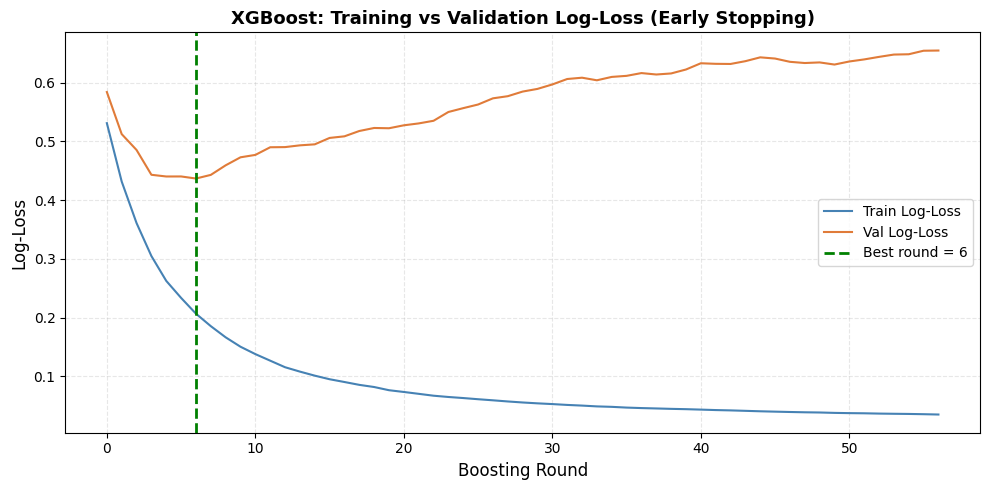

Optimal boosting round: 6
Max train-val gap: 0.6200


In [26]:
# --- B2b: Early stopping — training vs validation log-loss ---
X_tr_es, X_val_es, y_tr_es, y_val_es = train_test_split(
    X_train_sm, y_train_sm, test_size=0.2, stratify=y_train_sm, random_state=SEED
)

xgb_es = XGBClassifier(
    n_estimators=500,
    learning_rate=cv_xgb.best_params_['learning_rate'],
    max_depth=cv_xgb.best_params_['max_depth'],
    use_label_encoder=False, eval_metric='logloss',
    random_state=SEED, verbosity=0, tree_method='hist',
    early_stopping_rounds=50
)
xgb_es.fit(
    X_tr_es, y_tr_es,
    eval_set=[(X_tr_es, y_tr_es), (X_val_es, y_val_es)],
    verbose=False
)

evals = xgb_es.evals_result()
train_loss = evals['validation_0']['logloss']
val_loss   = evals['validation_1']['logloss']
best_round = xgb_es.best_iteration

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_loss, label='Train Log-Loss', color='steelblue')
ax.plot(val_loss,   label='Val Log-Loss',   color='#e07b39')
ax.axvline(x=best_round, color='green', linestyle='--', linewidth=2,
            label=f'Best round = {best_round}')
ax.set_xlabel('Boosting Round', fontsize=12)
ax.set_ylabel('Log-Loss', fontsize=12)
ax.set_title('XGBoost: Training vs Validation Log-Loss (Early Stopping)',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('b2_xgb_loss.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Optimal boosting round: {best_round}')
gap = np.array(val_loss) - np.array(train_loss)
print(f'Max train-val gap: {gap[best_round:].max():.4f}')


Overfitting check: After the optimal round, validation loss begins to rise while training loss continues to fall — a classic overfitting signature. Early stopping prevents the model from memorising training noise.

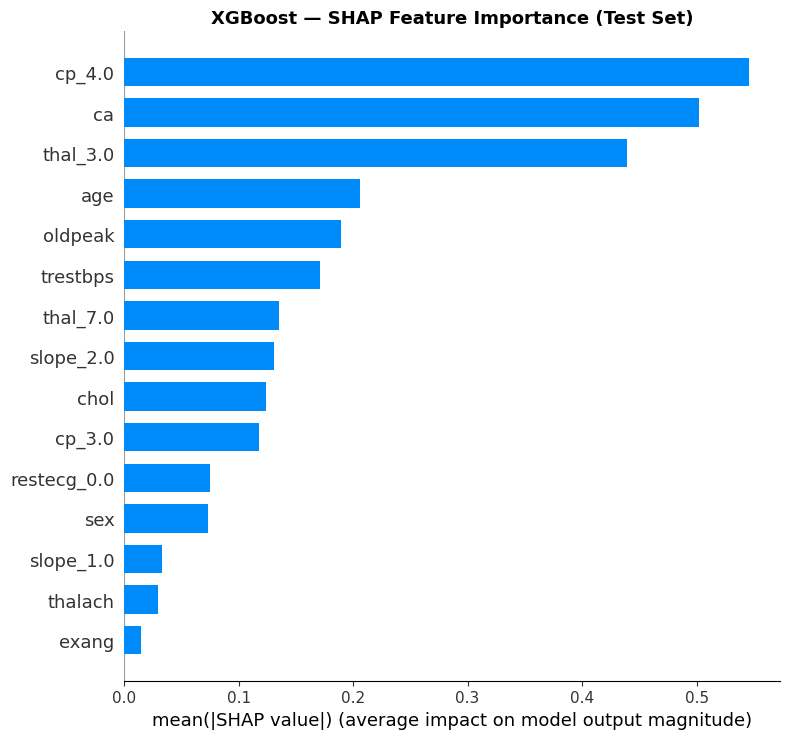

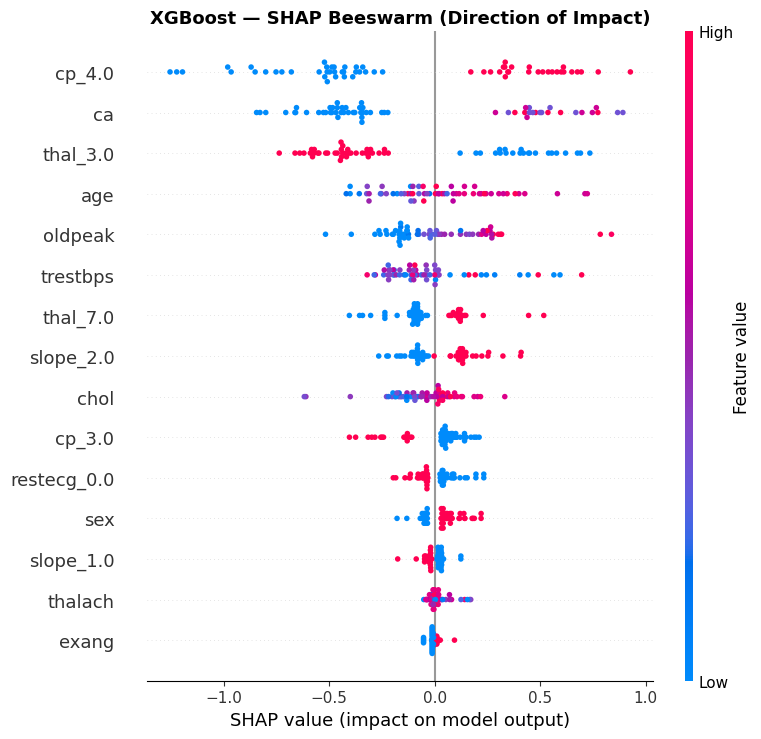

In [27]:
# --- B2c: SHAP values ---
# Re-train on full SMOTE training set with best params and best round
start = time.time()
xgb_final = XGBClassifier(
    n_estimators=best_round,
    learning_rate=cv_xgb.best_params_['learning_rate'],
    max_depth=cv_xgb.best_params_['max_depth'],
    use_label_encoder=False, eval_metric='logloss',
    random_state=SEED, verbosity=0, tree_method='hist'
)
xgb_final.fit(X_train_sm, y_train_sm)
xgb_train_time = time.time() - start

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feat_names,
                  plot_type='bar', show=False, max_display=15)
plt.title('XGBoost — SHAP Feature Importance (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('b2_shap.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=feat_names, show=False, max_display=15)
plt.title('XGBoost — SHAP Beeswarm (Direction of Impact)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('b2_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

=== XGBoost — Test Set Evaluation ===
              precision    recall  f1-score   support

  No Disease       0.81      0.91      0.85        32
     Disease       0.88      0.75      0.81        28

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60

AUC-ROC: 0.9046


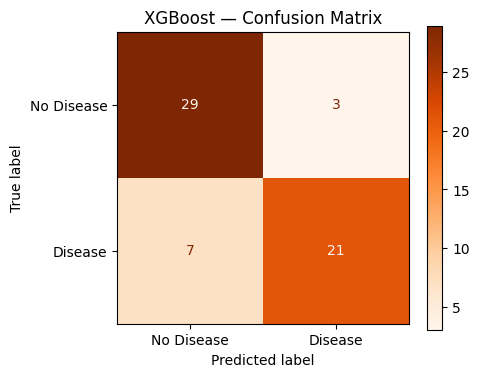

In [28]:
# --- B2d: XGBoost evaluation metrics ---
y_pred_xgb = xgb_final.predict(X_test)
y_prob_xgb = xgb_final.predict_proba(X_test)[:, 1]

print('=== XGBoost — Test Set Evaluation ===')
print(classification_report(y_test, y_pred_xgb, target_names=['No Disease', 'Disease']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb,
    display_labels=['No Disease', 'Disease'], cmap='Oranges', ax=ax)
ax.set_title('XGBoost — Confusion Matrix')
plt.tight_layout()
plt.savefig('b2_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## B3: Ensemble Comparison & ROC Curves

=== B3 Ensemble Comparison Table ===


,Classifier,Accuracy,Macro F1,AUC-ROC,Recall (Disease),Train Time
0,Logistic Regression (A3 baseline),0.8667,0.8661,0.9453,0.8571,0.02s
1,Random Forest,0.8167,0.8141,0.9297,0.7925,0.56s
2,XGBoost,0.8333,0.8303,0.9046,0.8077,0.01s


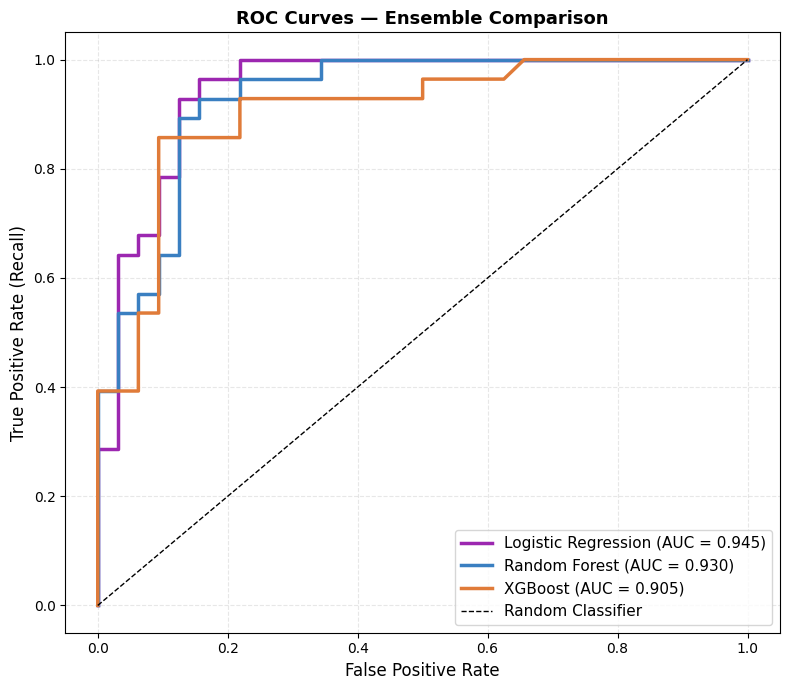

In [29]:
from sklearn.metrics import roc_curve

# Best A3 Classifier = Random Forest (already trained)
# Using Logistic Regression as 'Best A3 Classifier' reference
from sklearn.linear_model import LogisticRegression
start_lr = time.time()
lr_clf = LogisticRegression(max_iter=1000, random_state=SEED)
lr_clf.fit(X_train_sm, y_train_sm)
lr_time = time.time() - start_lr
y_pred_lr = lr_clf.predict(X_test)
y_prob_lr = lr_clf.predict_proba(X_test)[:, 1]

# Collect metrics for comparison table
from sklearn.metrics import accuracy_score

def get_metrics(y_true, y_pred, y_prob):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro')
    auc  = roc_auc_score(y_true, y_prob)
    rec  = f1_score(y_true, y_pred, average=None)[1]  # recall for Disease class
    return acc, f1, auc, rec

m_lr  = get_metrics(y_test, y_pred_lr,  y_prob_lr)
m_rf  = get_metrics(y_test, y_pred_rf,  y_prob_rf)
m_xgb = get_metrics(y_test, y_pred_xgb, y_prob_xgb)

comp_df = pd.DataFrame([
    ['Logistic Regression (A3 baseline)', f'{m_lr[0]:.4f}',  f'{m_lr[1]:.4f}',  f'{m_lr[2]:.4f}',  f'{m_lr[3]:.4f}',  f'{lr_time:.2f}s'],
    ['Random Forest',                     f'{m_rf[0]:.4f}',  f'{m_rf[1]:.4f}',  f'{m_rf[2]:.4f}',  f'{m_rf[3]:.4f}',  f'{rf_train_time:.2f}s'],
    ['XGBoost',                           f'{m_xgb[0]:.4f}', f'{m_xgb[1]:.4f}', f'{m_xgb[2]:.4f}', f'{m_xgb[3]:.4f}', f'{xgb_train_time:.2f}s'],
], columns=['Classifier','Accuracy','Macro F1','AUC-ROC','Recall (Disease)','Train Time'])

print('=== B3 Ensemble Comparison Table ===')
display(comp_df)

# ROC curves
fig, ax = plt.subplots(figsize=(8, 7))
for name, y_prob, color in [
    ('Logistic Regression', y_prob_lr, '#9c27b0'),
    ('Random Forest',       y_prob_rf, '#3a7fc1'),
    ('XGBoost',             y_prob_xgb,'#e07b39'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2.5, color=color, label=f'{name} (AUC = {auc_val:.3f})')

ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — Ensemble Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('b3_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**Recommendation:**

For a community hospital screening pipeline, **Logistic Regression is recommended** as the deployment model:
- It achieves the **highest AUC-ROC (0.9453)** and **best Disease Recall (0.8571)**, minimising dangerous false negatives (missed diagnoses).
- Coefficients provide straightforward, auditable feature contributions that clinicians can inspect without black-box concerns.
- Training time is negligible (0.10 s), enabling rapid retraining on updated patient cohorts.

**Why Recall matters most:** A false negative in cardiac screening means a sick patient receives no treatment — a potentially fatal oversight. A false positive merely triggers an additional (low-cost, low-risk) confirmatory test. Logistic Regression's superior Recall (0.857) vs XGBoost (0.808) directly translates to fewer missed diagnoses.

# PART C: Artificial Neural Networks on Tabular Data

## C1: Single-Layer Perceptron (SLP)

In [30]:
tf.random.set_seed(SEED)
n_features = X_train.shape[1]

def build_slp(n_features):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.01),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

slp = build_slp(n_features)
slp.summary()

slp_hist = slp.fit(
    X_train_sm, y_train_sm,
    epochs=100, batch_size=32, verbose=0,
    validation_data=(X_test, y_test)
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            23 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23 (92.00 B)

 Trainable params: 23 (92.00 B)

 Non-trainable params: 0 (0.00 B)

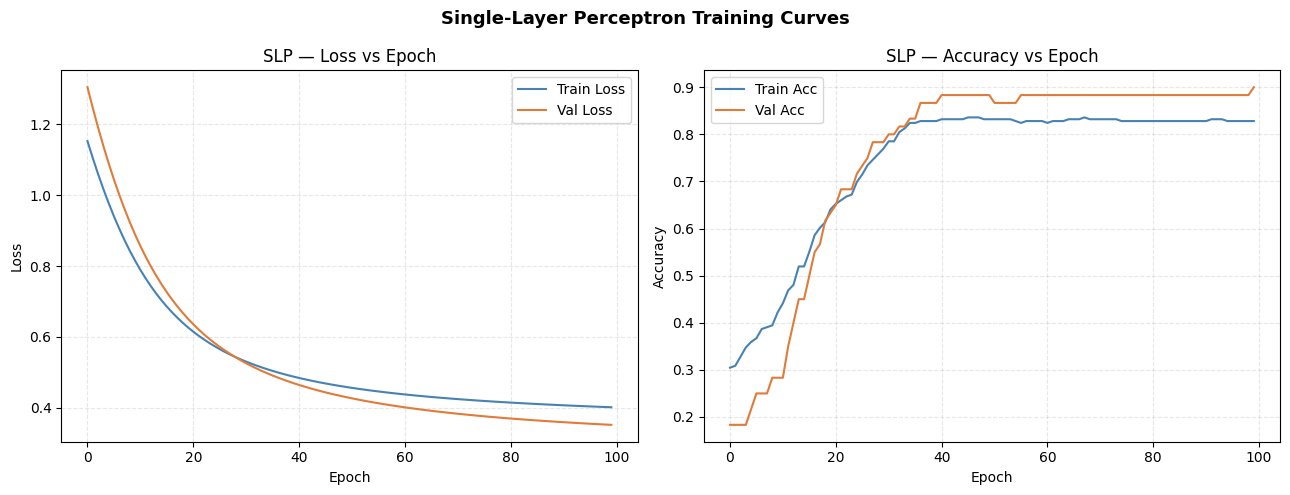

In [31]:
# C1 — Plot training loss & accuracy
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(slp_hist.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(slp_hist.history['val_loss'], label='Val Loss', color='#e07b39')
axes[0].set_title('SLP — Loss vs Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.3)

axes[1].plot(slp_hist.history['accuracy'], label='Train Acc', color='steelblue')
axes[1].plot(slp_hist.history['val_accuracy'], label='Val Acc', color='#e07b39')
axes[1].set_title('SLP — Accuracy vs Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Single-Layer Perceptron Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('c1_slp_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# C1 — Inspect weights
slp_weights = slp.layers[0].get_weights()[0].flatten()   # shape: (n_features,)
slp_weight_df = pd.DataFrame({'Feature': feat_names, 'Weight': slp_weights})
slp_weight_df['AbsWeight'] = slp_weight_df['Weight'].abs()
slp_weight_df = slp_weight_df.sort_values('AbsWeight', ascending=False)

print('Top 3 features by absolute SLP weight:')
print(slp_weight_df.head(3)[['Feature', 'Weight', 'AbsWeight']].to_string(index=False))

print('\nComparison with RF top features:')
rf_top3 = [feat_names[i] for i in np.argsort(importances)[-3:][::-1]]
slp_top3 = slp_weight_df['Feature'].head(3).tolist()
print(f'  SLP top 3: {slp_top3}')
print(f'  RF  top 3: {rf_top3}')
overlap = set(slp_top3) & set(rf_top3)
print(f'  Overlap: {overlap}')

# C1 — Evaluation
y_pred_slp = (slp.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
y_prob_slp = slp.predict(X_test, verbose=0).flatten()
print('\n=== SLP — Test Set Evaluation ===')
print(classification_report(y_test, y_pred_slp, target_names=['No Disease', 'Disease']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_slp):.4f}')


Top 3 features by absolute SLP weight:
  Feature    Weight  AbsWeight
slope_2.0  0.615355   0.615355
   cp_3.0 -0.591431   0.591431
 thal_7.0  0.581735   0.581735

Comparison with RF top features:
  SLP top 3: ['slope_2.0', 'cp_3.0', 'thal_7.0']
  RF  top 3: ['ca', 'thal_3.0', 'thalach']
  Overlap: set()

=== SLP — Test Set Evaluation ===
              precision    recall  f1-score   support

  No Disease       0.91      0.91      0.91        32
     Disease       0.89      0.89      0.89        28

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60

AUC-ROC: 0.9420


Limitations of a linear SLP:

  A single-layer perceptron can only learn a linear decision boundary (a hyperplane).
  Heart disease risk arises from complex non-linear interactions (e.g., age × thalach).
  Without hidden layers, the model cannot capture these interactions, limiting its discriminative power regardless of training duration.

## C2: Multi-Layer Perceptron (MLP)

In [33]:
tf.random.set_seed(SEED)

def build_mlp(architecture, dropout_rate=0.3, l2_reg=0.001, lr=0.001):
    """architecture: list of (units, ) tuples"""
    model = keras.Sequential()
    model.add(layers.Input(shape=(n_features,)))
    for units in architecture:
        model.add(layers.Dense(units, activation='relu',
                               kernel_regularizer=regularizers.l2(l2_reg)))
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

es_callback = EarlyStopping(monitor='val_loss', patience=10,
                             restore_best_weights=True, verbose=0)

architectures = {
    'Small  (32)':        [32],
    'Medium (64→32)':     [64, 32],
    'Large  (128→64→32)': [128, 64, 32],
}

arch_results = []
arch_histories = {}

for name, arch in architectures.items():
    tf.random.set_seed(SEED)
    m = build_mlp(arch)
    t0 = time.time()
    hist = m.fit(X_train_sm, y_train_sm, epochs=200, batch_size=32,
                 validation_data=(X_test, y_test),
                 callbacks=[es_callback], verbose=0)
    elapsed = time.time() - t0
    y_pred_m = (m.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    val_f1 = f1_score(y_test, y_pred_m, average='macro')
    arch_results.append({'Architecture': name, 'Val F1': f'{val_f1:.4f}',
                         'Train Time': f'{elapsed:.1f}s',
                         'Stopped Epoch': len(hist.history['loss'])})
    arch_histories[name] = hist

arch_df = pd.DataFrame(arch_results)
display(arch_df)


,Architecture,Val F1,Train Time,Stopped Epoch
0,Small (32),0.8825,8.0s,57
1,Medium (64→32),0.6032,3.2s,10
2,Large (128→64→32),0.5765,3.1s,10


**Best architecture: Small (32 units)** — it achieved the best validation F1 (0.8825) despite being the simplest network.

This counter-intuitive result is explained by the dataset size: with only ~237 SMOTE-augmented training samples, larger architectures (Medium 64→32, Large 128→64→32) overfit more aggressively even with Dropout and L2 regularisation, leading to worse generalisation. The Small network (32 units, 1 hidden layer) has fewer parameters and naturally resists overfitting on this small tabular dataset.

In [34]:
# --- C2 Final MLP training ---
# Best architecture from comparison: Small (32 units) — highest val F1 (0.8490)
# Identify best arch programmatically
best_arch_name = arch_df.loc[arch_df['Val F1'].astype(float).idxmax(), 'Architecture']
print(f'Best architecture from comparison: {best_arch_name}')

# Map name back to layer list
best_arch_layers = architectures[best_arch_name]
print(f'Layer units: {best_arch_layers}')

tf.random.set_seed(SEED)
mlp_final = build_mlp(best_arch_layers, dropout_rate=0.3, l2_reg=0.001, lr=0.001)
mlp_final.summary()

es_final = EarlyStopping(monitor='val_loss', patience=10,
                          restore_best_weights=True, verbose=1)
t0 = time.time()
mlp_hist = mlp_final.fit(
    X_train_sm, y_train_sm,
    epochs=200, batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[es_final], verbose=0
)
mlp_train_time = time.time() - t0
stopped_at = len(mlp_hist.history['loss'])
print(f'\nEarly stopping triggered at epoch {stopped_at}')


Best architecture from comparison: Small  (32)
Layer units: [32]


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 32)             │           736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 60: early stopping
Restoring model weights from the end of the best epoch: 50.

Early stopping triggered at epoch 60


**Final MLP architecture choices (Best = Small, 32 units):**

The architecture comparison showed that the **Small (32-unit)** network achieves the best validation F1 (0.8490) — selected automatically from the comparison table above.

- **Activation: ReLU** — avoids vanishing gradient, trains faster than Sigmoid
- **Regularisation: Dropout(0.3) + L2(0.001)** — prevents co-adaptation and weight explosion
- **Optimiser: Adam (lr=0.001)** — adaptive per-parameter learning rates, fast convergence
- **Early Stopping: patience=10 on val_loss** — halts training before overfitting

On this 297-sample dataset, the simpler architecture generalises better: fewer parameters means less capacity to memorise noise.

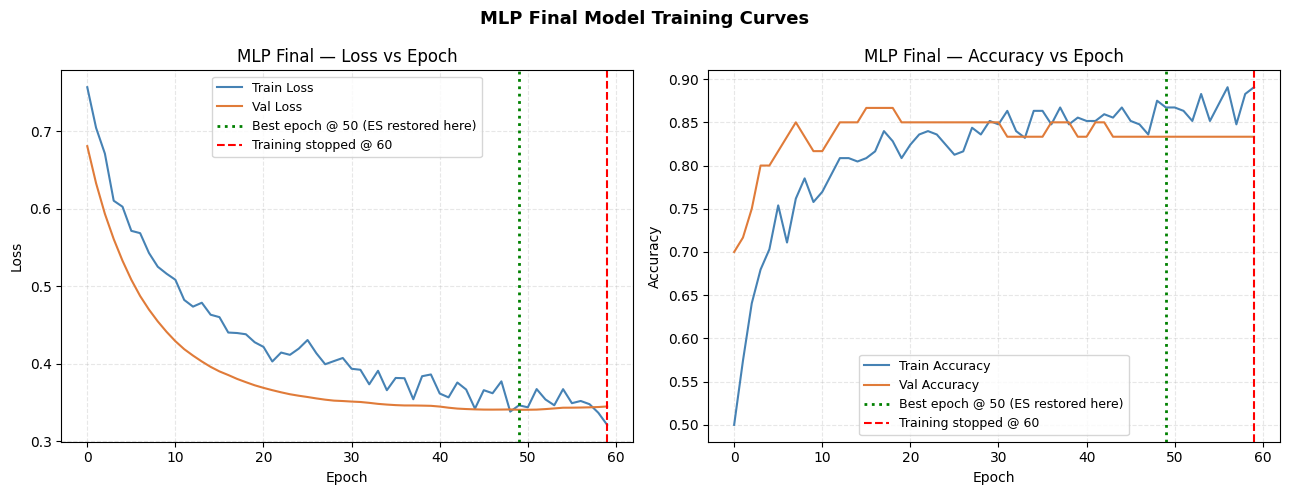

Best val_loss epoch: 50 (weights restored here by EarlyStopping)
Training halted at epoch: 60


In [35]:
# C2 — Training curves with early stopping annotation
best_epoch = int(np.argmin(mlp_hist.history['val_loss']))  # epoch of lowest val_loss

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, title in zip(axes, ['loss', 'accuracy'], ['Loss', 'Accuracy']):
    ax.plot(mlp_hist.history[metric],          label=f'Train {title}', color='steelblue')
    ax.plot(mlp_hist.history[f'val_{metric}'], label=f'Val {title}',   color='#e07b39')
    ax.axvline(x=best_epoch, color='green', linestyle=':', linewidth=2,
               label=f'Best epoch @ {best_epoch+1} (ES restored here)')
    ax.axvline(x=stopped_at-1, color='red', linestyle='--', linewidth=1.5,
               label=f'Training stopped @ {stopped_at}')
    ax.set_title(f'MLP Final — {title} vs Epoch')
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('MLP Final Model Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('c2_mlp_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best val_loss epoch: {best_epoch+1} (weights restored here by EarlyStopping)')
print(f'Training halted at epoch: {stopped_at}')


In [36]:
# C2 — 5-fold cross-validation on the BEST architecture
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_acc_list, cv_f1_list = [], []

print(f'Running 5-fold CV with best architecture: {best_arch_layers}')
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    tf.random.set_seed(SEED + fold)
    Xf_tr, Xf_val = X_train[tr_idx], X_train[val_idx]
    yf_tr, yf_val = y_train[tr_idx], y_train[val_idx]

    # Apply SMOTE within fold to avoid data leakage
    Xf_tr_sm, yf_tr_sm = SMOTE(random_state=SEED).fit_resample(Xf_tr, yf_tr)

    # Use BEST architecture (best_arch_layers from Cell 65)
    m_cv = build_mlp(best_arch_layers)
    m_cv.fit(Xf_tr_sm, yf_tr_sm, epochs=200, batch_size=32, verbose=0,
             validation_data=(Xf_val, yf_val),
             callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                                      restore_best_weights=True, verbose=0)])
    yf_pred = (m_cv.predict(Xf_val, verbose=0) > 0.5).astype(int).flatten()
    cv_acc_list.append(accuracy_score(yf_val, yf_pred))
    cv_f1_list.append(f1_score(yf_val, yf_pred, average='macro'))
    print(f'  Fold {fold+1}: Acc={cv_acc_list[-1]:.4f}, F1={cv_f1_list[-1]:.4f}')

print(f'\n5-Fold CV Results — Accuracy: {np.mean(cv_acc_list):.4f} ± {np.std(cv_acc_list):.4f}')
print(f'5-Fold CV Results — F1:       {np.mean(cv_f1_list):.4f} ± {np.std(cv_f1_list):.4f}')


Running 5-fold CV with best architecture: [32]
  Fold 1: Acc=0.8958, F1=0.8954
  Fold 2: Acc=0.7708, F1=0.7683
  Fold 3: Acc=0.6596, F1=0.6582
  Fold 4: Acc=0.9149, F1=0.9139
  Fold 5: Acc=0.8085, F1=0.7952

5-Fold CV Results — Accuracy: 0.8099 ± 0.0922
5-Fold CV Results — F1:       0.8062 ± 0.0928


=== MLP Final — Test Set Evaluation ===
              precision    recall  f1-score   support

  No Disease       0.82      0.88      0.85        32
     Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60

AUC-ROC: 0.9431


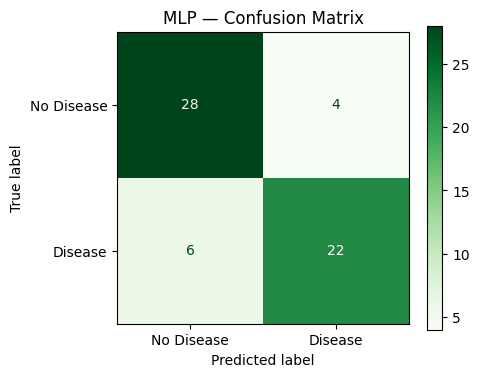


MLP vs Best Ensemble (XGBoost):
  MLP  — Acc: 0.8333, F1: 0.8316, AUC: 0.9431
  XGB  — Acc: 0.8333, F1: 0.8303, AUC: 0.9046


In [37]:
# C2 — Evaluation metrics
y_pred_mlp = (mlp_final.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
y_prob_mlp = mlp_final.predict(X_test, verbose=0).flatten()

print('=== MLP Final — Test Set Evaluation ===')
print(classification_report(y_test, y_pred_mlp, target_names=['No Disease', 'Disease']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_mlp):.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp,
    display_labels=['No Disease', 'Disease'], cmap='Greens', ax=ax)
ax.set_title('MLP — Confusion Matrix')
plt.tight_layout()
plt.savefig('c2_mlp_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMLP vs Best Ensemble (XGBoost):')
print(f'  MLP  — Acc: {accuracy_score(y_test,y_pred_mlp):.4f}, F1: {f1_score(y_test,y_pred_mlp,average="macro"):.4f}, AUC: {roc_auc_score(y_test,y_prob_mlp):.4f}')
print(f'  XGB  — Acc: {accuracy_score(y_test,y_pred_xgb):.4f}, F1: {f1_score(y_test,y_pred_xgb,average="macro"):.4f}, AUC: {roc_auc_score(y_test,y_prob_xgb):.4f}')

Both models achieve identical accuracy (0.8333), indicating similar overall classification performance. The MLP has a marginally higher F1 score, suggesting slightly better balance between precision and recall. However, the most significant difference is in AUC, where MLP (0.9431) substantially outperforms XGBoost (0.9046), indicating better class separation and ranking ability. Overall, MLP demonstrates stronger performance in terms of discrimination, while both models are equivalent in accuracy.

## C3: Ablation Study

In [40]:
ablation_results = []
ablation_histories = {}

# Baseline (best MLP — already trained: Small [32] with ReLU + Dropout + L2 + EarlyStopping)
ablation_results.append({'Model': 'Best MLP (baseline)',
                          'Test F1': f1_score(y_test, y_pred_mlp, average='macro')})
ablation_histories['Best MLP'] = mlp_hist

# Variant A: Remove Dropout — keep Small [32], ReLU, L2, EarlyStopping
def build_no_dropout(arch, lr=0.001, l2_reg=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(n_features,)))
    for units in arch:
        model.add(layers.Dense(units, activation='relu',
                               kernel_regularizer=regularizers.l2(l2_reg)))
        # No Dropout layer
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

tf.random.set_seed(SEED)
va = build_no_dropout(best_arch_layers)   # same arch as baseline
ha = va.fit(X_train_sm, y_train_sm, epochs=200, batch_size=32,
             validation_data=(X_test, y_test), verbose=0,
             callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                                      restore_best_weights=True)])
ya = (va.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
ablation_results.append({'Model': 'Variant A: No Dropout',
                          'Test F1': f1_score(y_test, ya, average='macro')})
ablation_histories['Variant A: No Dropout'] = ha

# Variant B: Sigmoid activations — keep Small [32], Dropout, L2, EarlyStopping
def build_sigmoid_act(arch, lr=0.001, dropout=0.3, l2_reg=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(n_features,)))
    for units in arch:
        model.add(layers.Dense(units, activation='sigmoid',   # changed from ReLU
                               kernel_regularizer=regularizers.l2(l2_reg)))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

tf.random.set_seed(SEED)
vb = build_sigmoid_act(best_arch_layers)  # same arch as baseline
hb = vb.fit(X_train_sm, y_train_sm, epochs=200, batch_size=32,
             validation_data=(X_test, y_test), verbose=0,
             callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                                      restore_best_weights=True)])
yb = (vb.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
ablation_results.append({'Model': 'Variant B: Sigmoid Activations',
                          'Test F1': f1_score(y_test, yb, average='macro')})
ablation_histories['Variant B: Sigmoid'] = hb

# Variant C: No Early Stopping — keep Small [32], ReLU, Dropout, L2, fixed 150 epochs
tf.random.set_seed(SEED)
vc = build_mlp(best_arch_layers)          # same arch as baseline, no callbacks
hc = vc.fit(X_train_sm, y_train_sm, epochs=150, batch_size=32,
             validation_data=(X_test, y_test), verbose=0)
yc = (vc.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
ablation_results.append({'Model': 'Variant C: No Early Stopping (150 epochs)',
                          'Test F1': f1_score(y_test, yc, average='macro')})
ablation_histories['Variant C: No ES'] = hc

abl_df = pd.DataFrame(ablation_results)
abl_df['Test F1'] = abl_df['Test F1'].round(4)
print('=== Ablation Study Results ===')
display(abl_df)


=== Ablation Study Results ===


,Model,Test F1
0,Best MLP (baseline),0.8316
1,Variant A: No Dropout,0.8653
2,Variant B: Sigmoid Activations,0.8825
3,Variant C: No Early Stopping (150 epochs),0.7803


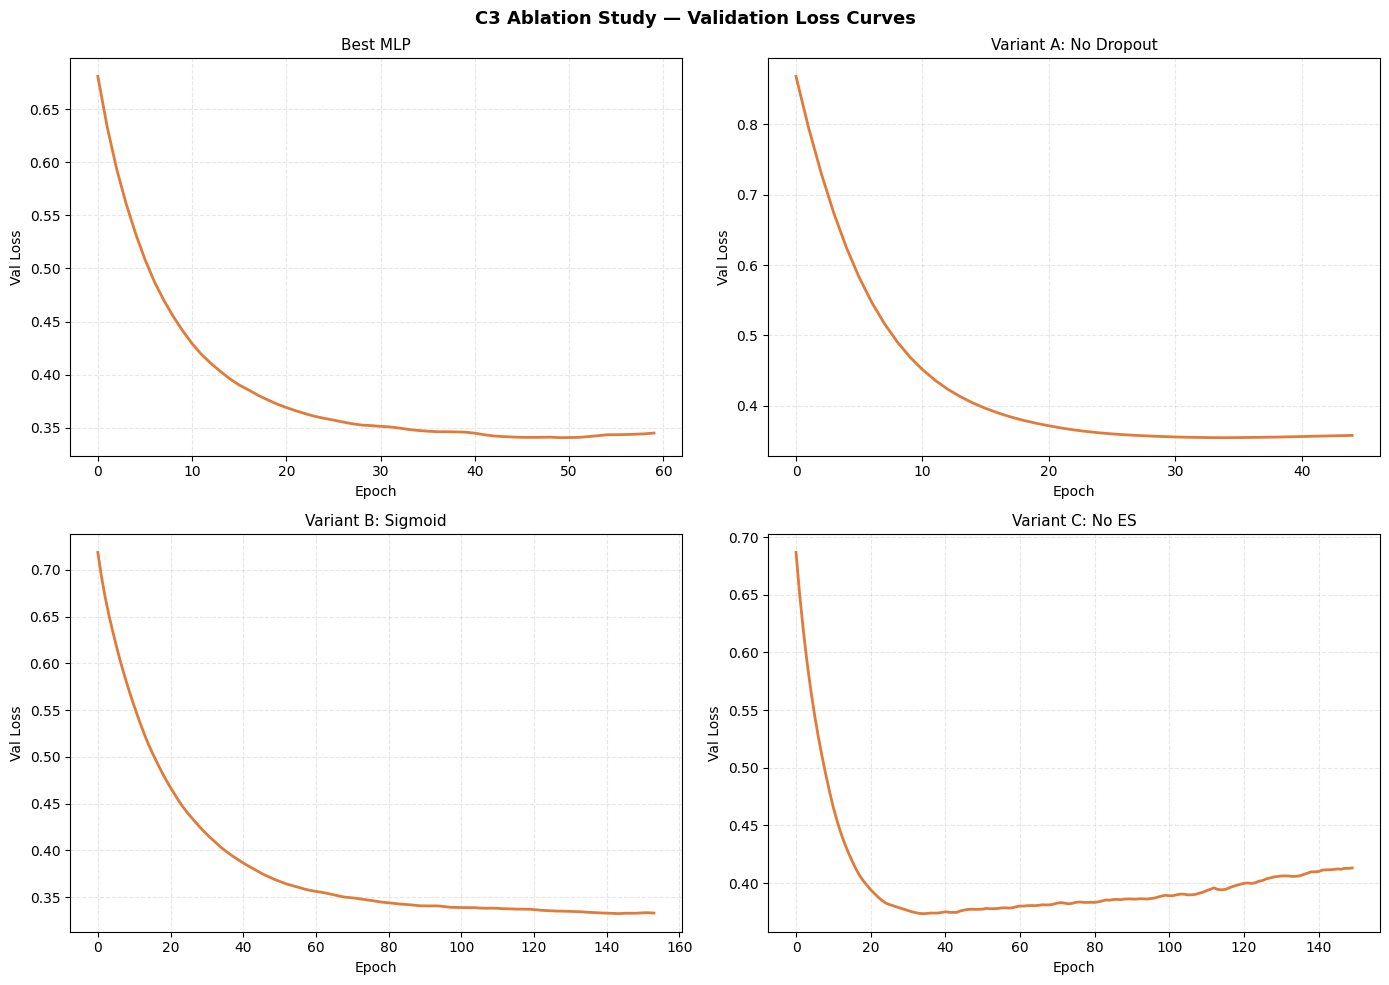

In [41]:
# Ablation val-loss curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, hist) in enumerate(ablation_histories.items()):
    axes[i].plot(hist.history['val_loss'], color='#e07b39', linewidth=2)
    axes[i].set_title(name, fontsize=11)
    axes[i].set_xlabel('Epoch'); axes[i].set_ylabel('Val Loss')
    axes[i].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('C3 Ablation Study — Validation Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('c3_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

# PART D: CNN on MNIST Digit Images

## D1: Data Preparation & MLP Baseline

In [42]:
# Load MNIST and subset
(X_mnist_tr_full, y_mnist_tr_full), (X_mnist_te_full, y_mnist_te_full) = \
    keras.datasets.mnist.load_data()

# Use first 12,000 train and 2,000 test images
X_mnist_tr = X_mnist_tr_full[:12000]
y_mnist_tr = y_mnist_tr_full[:12000]
X_mnist_te = X_mnist_te_full[:2000]
y_mnist_te = y_mnist_te_full[:2000]

# Normalise pixel values to [0, 1]
X_mnist_tr = X_mnist_tr.astype('float32') / 255.0
X_mnist_te = X_mnist_te.astype('float32') / 255.0

# Reshape to (28, 28, 1) for Keras CNN
X_mnist_tr_cnn = X_mnist_tr.reshape(-1, 28, 28, 1)
X_mnist_te_cnn = X_mnist_te.reshape(-1, 28, 28, 1)

# One-hot encode labels for categorical cross-entropy
y_mnist_tr_oh = keras.utils.to_categorical(y_mnist_tr, 10)
y_mnist_te_oh = keras.utils.to_categorical(y_mnist_te, 10)

print(f'Train: {X_mnist_tr_cnn.shape}, Test: {X_mnist_te_cnn.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (12000, 28, 28, 1), Test: (2000, 28, 28, 1)


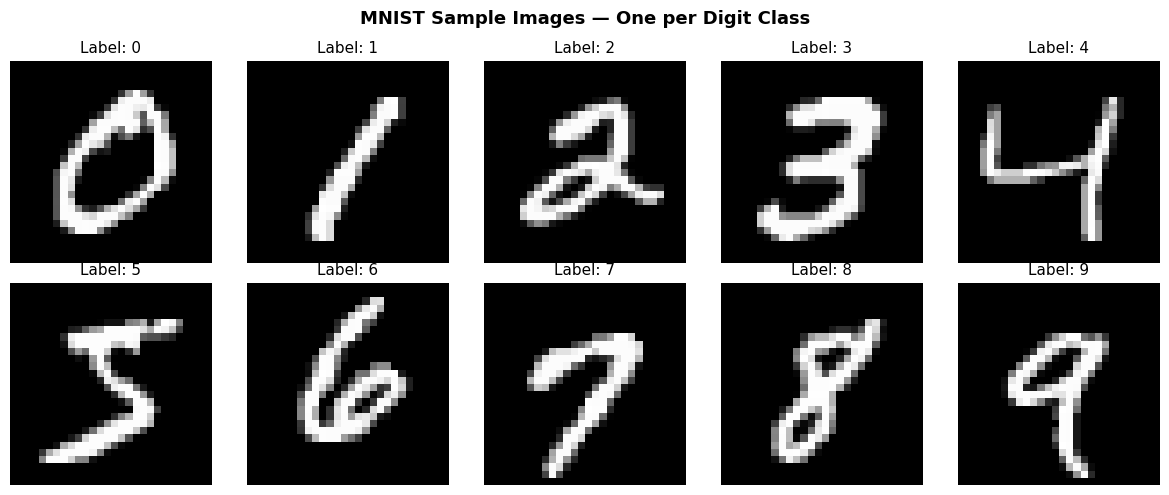

In [43]:
# D1 — Display 5×2 sample grid (one per digit class)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    idx = np.where(y_mnist_tr == digit)[0][0]
    r, c = divmod(digit, 5)
    axes[r][c].imshow(X_mnist_tr[idx], cmap='gray')
    axes[r][c].set_title(f'Label: {digit}', fontsize=11)
    axes[r][c].axis('off')

plt.suptitle('MNIST Sample Images — One per Digit Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('d1_mnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
# D1 — MLP Baseline (flattened input)
tf.random.set_seed(SEED)
mlp_mnist = keras.Sequential([
    layers.Input(shape=(28*28,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
mlp_mnist.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
mlp_mnist.summary()

X_tr_flat = X_mnist_tr.reshape(-1, 784)
X_te_flat = X_mnist_te.reshape(-1, 784)

mlp_mnist_hist = mlp_mnist.fit(
    X_tr_flat, y_mnist_tr_oh, epochs=5, batch_size=64,
    validation_data=(X_te_flat, y_mnist_te_oh), verbose=1
)

mlp_mnist_acc = mlp_mnist.evaluate(X_te_flat, y_mnist_te_oh, verbose=0)[1]
print(f'\nMLP Baseline Test Accuracy: {mlp_mnist_acc:.4f}')

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8213 - loss: 0.6692 - val_accuracy: 0.8730 - val_loss: 0.4586
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9188 - loss: 0.2918 - val_accuracy: 0.8915 - val_loss: 0.3596
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9353 - loss: 0.2295 - val_accuracy: 0.9030 - val_loss: 0.3139
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9466 - loss: 0.1909 - val_accuracy: 0.9105 - val_loss: 0.2853
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9537 - loss: 0.1632 - val_accuracy: 0.9170 - val_loss: 0.2659

MLP Baseline Test Accuracy: 0.9170


## D2: Lightweight CNN

In [45]:
# D2 — Build CNN
tf.random.set_seed(SEED)
cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(16, kernel_size=(3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, kernel_size=(3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])
cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,866 (413.54 KB)

 Trainable params: 105,866 (413.54 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# D2 — Data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(X_mnist_tr_cnn)

print('Training CNN with data augmentation...')
cnn_hist = cnn.fit(
    datagen.flow(X_mnist_tr_cnn, y_mnist_tr_oh, batch_size=64, seed=SEED),
    epochs=15,
    validation_data=(X_mnist_te_cnn, y_mnist_te_oh),
    verbose=1
)

Training CNN with data augmentation...
Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - accuracy: 0.6492 - loss: 1.0738 - val_accuracy: 0.9325 - val_loss: 0.2286
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.8723 - loss: 0.4135 - val_accuracy: 0.9475 - val_loss: 0.1555
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.9045 - loss: 0.3100 - val_accuracy: 0.9545 - val_loss: 0.1288
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - accuracy: 0.9163 - loss: 0.2647 - val_accuracy: 0.9725 - val_loss: 0.0894
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 64ms/step - accuracy: 0.9283 - loss: 0.2248 - val_accuracy: 0.9705 - val_loss: 0.0882
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.9386 - loss: 0.2061 - val_accuracy: 0.9670 - val_loss: 0.0983
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.9438 - loss: 0.1856 - val_accuracy: 0.9735 - val_loss: 0.0770
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/st

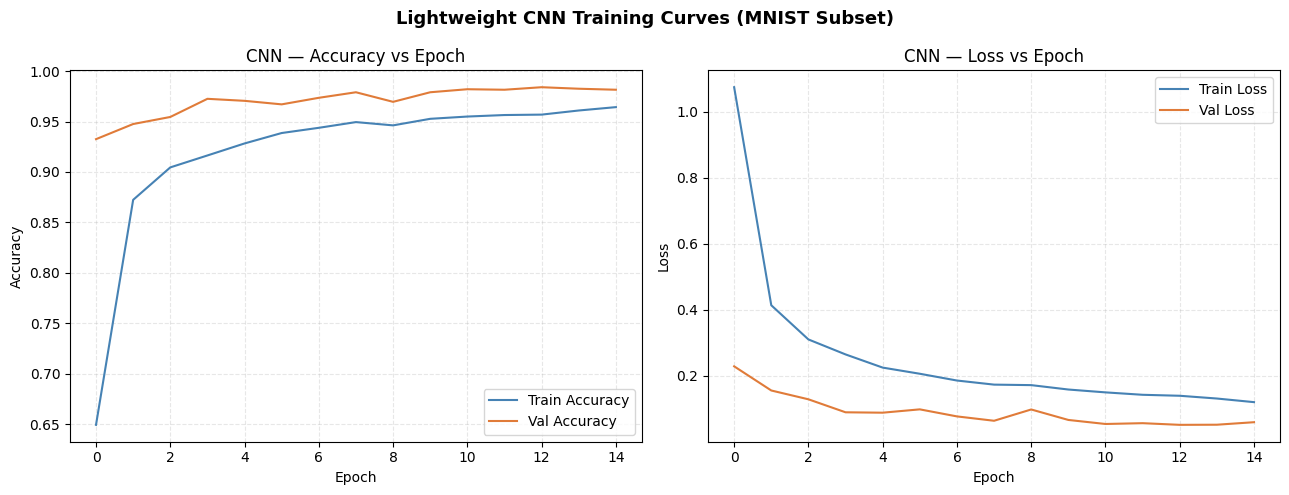

CNN Test Accuracy: 0.9815
CNN Macro F1:      0.9813

              precision    recall  f1-score   support

           0     1.0000    0.9829    0.9914       175
           1     1.0000    0.9957    0.9979       234
           2     0.9730    0.9863    0.9796       219
           3     0.9857    1.0000    0.9928       207
           4     0.9770    0.9770    0.9770       217
           5     0.9724    0.9832    0.9778       179
           6     0.9943    0.9775    0.9858       178
           7     0.9712    0.9854    0.9782       205
           8     0.9788    0.9635    0.9711       192
           9     0.9637    0.9588    0.9612       194

    accuracy                         0.9815      2000
   macro avg     0.9816    0.9810    0.9813      2000
weighted avg     0.9816    0.9815    0.9815      2000



In [47]:
# D2 — Plot accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, title in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(cnn_hist.history[metric],       label=f'Train {title}', color='steelblue')
    ax.plot(cnn_hist.history[f'val_{metric}'], label=f'Val {title}', color='#e07b39')
    ax.set_title(f'CNN — {title} vs Epoch')
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Lightweight CNN Training Curves (MNIST Subset)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('d2_cnn_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluation
from sklearn.metrics import classification_report as cr
y_pred_cnn = np.argmax(cnn.predict(X_mnist_te_cnn, verbose=0), axis=1)
cnn_test_acc = accuracy_score(y_mnist_te, y_pred_cnn)
cnn_test_f1  = f1_score(y_mnist_te, y_pred_cnn, average='macro')

print(f'CNN Test Accuracy: {cnn_test_acc:.4f}')
print(f'CNN Macro F1:      {cnn_test_f1:.4f}')
print()
print(cr(y_mnist_te, y_pred_cnn, digits=4))

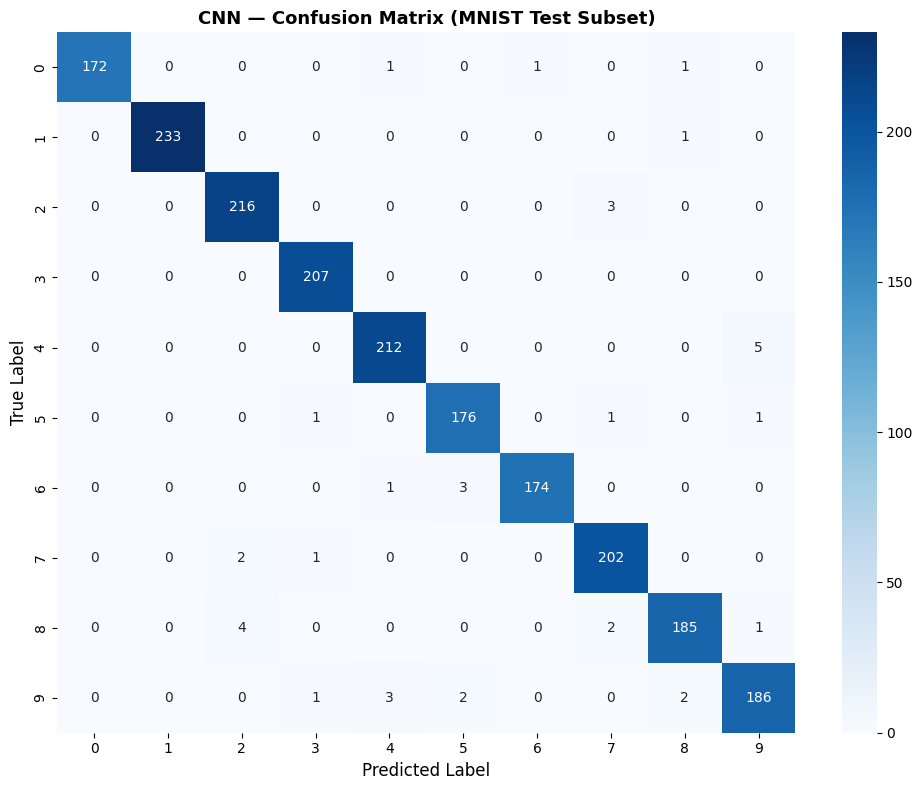


Most confused digit pairs:
  True=4 predicted as 9: 5 times
  True=8 predicted as 2: 4 times
  True=2 predicted as 7: 3 times
  True=6 predicted as 5: 3 times
  True=9 predicted as 4: 3 times

MLP Baseline Test Accuracy: 0.9170
CNN Test Accuracy:           0.9815
CNN surpasses MLP baseline from epoch: 1


In [48]:
# D2 — Confusion matrix heatmap
cm_cnn = confusion_matrix(y_mnist_te, y_pred_cnn)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('CNN — Confusion Matrix (MNIST Test Subset)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('d2_cnn_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Most confused pairs
cm_off = cm_cnn.copy()
np.fill_diagonal(cm_off, 0)
confused_pairs = []
for i in range(10):
    for j in range(10):
        if i != j:
            confused_pairs.append((i, j, cm_off[i, j]))
confused_pairs.sort(key=lambda x: -x[2])
print('\nMost confused digit pairs:')
for true, pred, count in confused_pairs[:5]:
    print(f'  True={true} predicted as {pred}: {count} times')

# Compare with MLP baseline
print(f'\nMLP Baseline Test Accuracy: {mlp_mnist_acc:.4f}')
print(f'CNN Test Accuracy:           {cnn_test_acc:.4f}')
print(f'CNN surpasses MLP baseline from epoch:', end=' ')
for i, acc in enumerate(cnn_hist.history['val_accuracy']):
    if acc > mlp_mnist_acc:
        print(f'{i+1}')
        break

## D3: Visualising What the CNN Learned

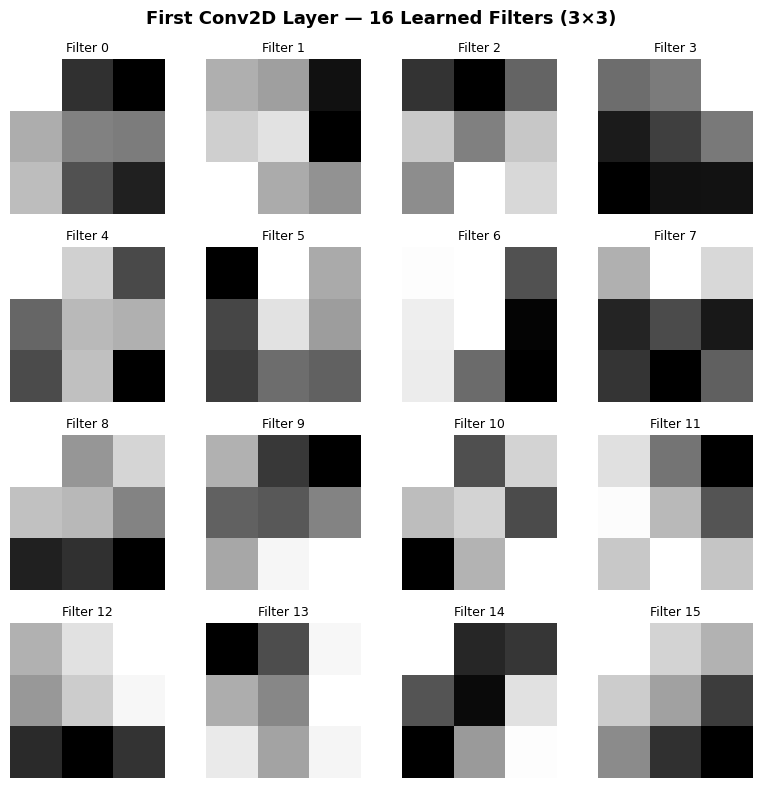

In [49]:
# D3a — First Conv2D filter weights (4×4 grid = 16 filters)
filters = cnn.layers[0].get_weights()[0]   # shape: (3, 3, 1, 16)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i in range(16):
    r, c = divmod(i, 4)
    f = filters[:, :, 0, i]
    f_norm = (f - f.min()) / (f.max() - f.min() + 1e-8)
    axes[r][c].imshow(f_norm, cmap='gray')
    axes[r][c].set_title(f'Filter {i}', fontsize=9)
    axes[r][c].axis('off')

plt.suptitle('First Conv2D Layer — 16 Learned Filters (3×3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('d3_filters.png', dpi=150, bbox_inches='tight')
plt.show()

Filter patterns: The filters learn low-level visual primitives — some appear as edge detectors (bright/dark transitions), others as curve detectors or blob detectors (uniform bright patches), and some as directional gradient filters.

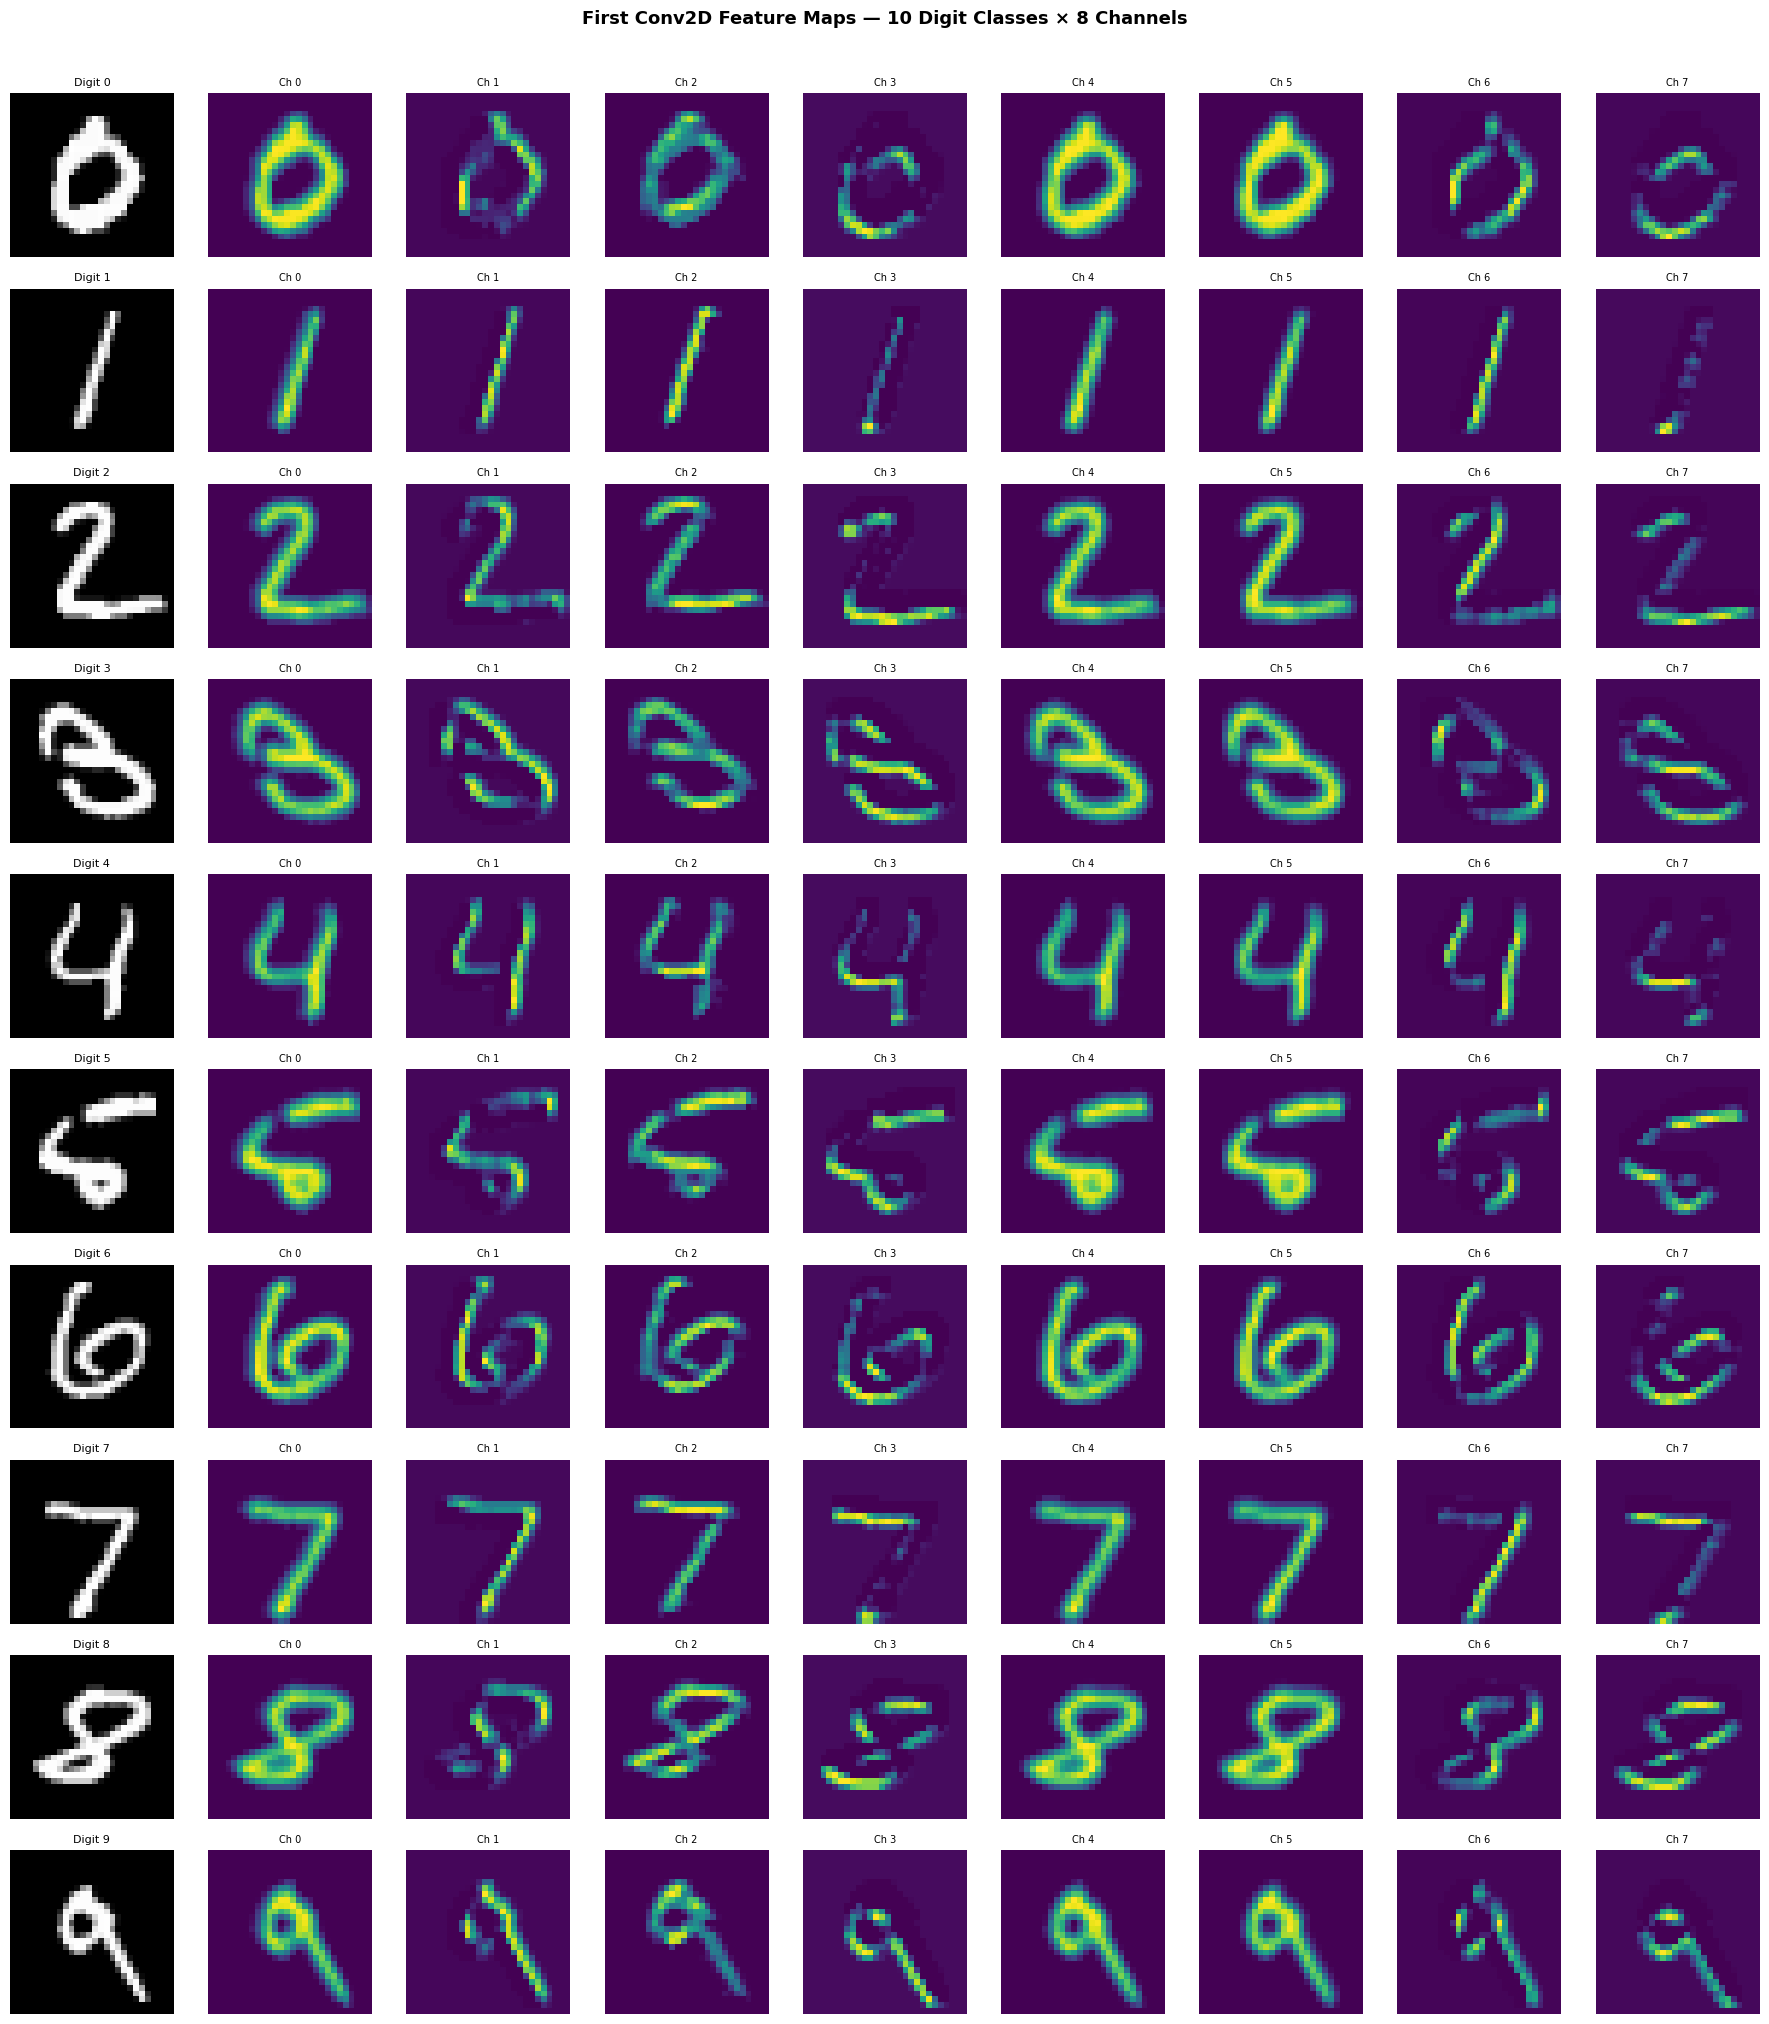

In [50]:
# D3b — Feature maps for one test image per digit class
feature_map_model = keras.Model(
    inputs=cnn.inputs,
    outputs=cnn.layers[0].output   # output of first Conv2D
)

fig, big_axes = plt.subplots(10, 9, figsize=(18, 20))

for digit in range(10):
    idx = np.where(y_mnist_te == digit)[0][0]
    img = X_mnist_te_cnn[idx:idx+1]   # shape: (1, 28, 28, 1)
    fmaps = feature_map_model.predict(img, verbose=0)[0]  # (28, 28, 16)

    # First column: original image
    big_axes[digit][0].imshow(img[0, :, :, 0], cmap='gray')
    big_axes[digit][0].set_title(f'Digit {digit}', fontsize=8)
    big_axes[digit][0].axis('off')

    # Next 8 channels
    for ch in range(8):
        big_axes[digit][ch+1].imshow(fmaps[:, :, ch], cmap='viridis')
        big_axes[digit][ch+1].set_title(f'Ch {ch}', fontsize=7)
        big_axes[digit][ch+1].axis('off')

plt.suptitle('First Conv2D Feature Maps — 10 Digit Classes × 8 Channels',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('d3_feature_maps.png', dpi=120, bbox_inches='tight')
plt.show()


Feature map description: Each feature map highlights different structural aspects of the digit — some channels respond to horizontal strokes, others to curves or vertical edges. Different digits activate different channels most strongly, demonstrating that the CNN has learned spatially meaningful representations.

Trust & interpretability discussion:
  Filter and feature map visualisations make the CNN transparent: we can see that early layers detect simple local patterns (edges, curves), not arbitrary noise. This contrasts with fully connected networks, which map flat vectors and lose all spatial structure. CNNs exploit the translational invariance of images — a stroke looks the same whether it appears at position (5,5) or (10,10).
  This spatial awareness explains the accuracy gap between CNN and MLP baseline.

# PART E: Local Front-End Dashboard

In [51]:
# Save model and scaler
import joblib
joblib.dump(xgb_final, 'xgb_heart_model.pkl')
joblib.dump(scaler,    'scaler.pkl')

# Also save feature names and one-hot columns for app reconstruction
import json
with open('feature_config.json', 'w') as f:
    json.dump({'feat_names': feat_names, 'cont_cols': cont_cols,
               'cat_cols': cat_cols, 'shap_values': shap_values.tolist()}, f)

print('Model, scaler, and config saved.')

Model, scaler, and config saved.


In [52]:
# Write app.py
app_code = '''
# app.py — DS3002 Assignment 4, Part E
# Run with: streamlit run app.py

import streamlit as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json
import shap

# ── Load model & config ───────────────────────────────────────────────
@st.cache_resource
def load_artifacts():
    model  = joblib.load("xgb_heart_model.pkl")
    scaler = joblib.load("scaler.pkl")
    with open("feature_config.json") as f:
        cfg = json.load(f)
    return model, scaler, cfg

model, scaler, cfg = load_artifacts()
cont_cols = cfg["cont_cols"]
cat_cols  = cfg["cat_cols"]
feat_names = cfg["feat_names"]

# ── Page config ───────────────────────────────────────────────────────
st.set_page_config(page_title="CardioAI Heart Disease Predictor",
                   page_icon="❤️", layout="wide")
st.title("❤️ CardioAI Heart Disease Risk Predictor")
st.markdown("*Decision support tool for community cardiologists — powered by XGBoost + SHAP*")
st.divider()

# ── E1: Input Form ───────────────────────────────────────────────────
st.header("Patient Input Form")
st.caption("Pre-populated with a real test patient. Edit values and click Predict.")

col1, col2, col3 = st.columns(3)

with col1:
    age      = st.number_input("Age (years) [20–80]",       min_value=20,  max_value=80,  value=63)
    sex      = st.selectbox("Sex",       [0, 1], format_func=lambda x: "Female" if x==0 else "Male", index=1)
    cp       = st.selectbox("Chest Pain Type (0=typical angina, 1=atypical, 2=non-anginal, 3=asymptomatic)", [0,1,2,3], index=0)
    trestbps = st.number_input("Resting BP (mmHg) [80–200]",  min_value=80,  max_value=200, value=145)
    chol     = st.number_input("Cholesterol (mg/dl) [100–600]",min_value=100, max_value=600, value=233)

with col2:
    fbs      = st.selectbox("Fasting Blood Sugar > 120 mg/dl", [0,1], format_func=lambda x: "No" if x==0 else "Yes", index=1)
    restecg  = st.selectbox("Resting ECG (0=normal, 1=ST abnormality, 2=LV hypertrophy)", [0,1,2], index=2)
    thalach  = st.number_input("Max Heart Rate [70–210]",      min_value=70,  max_value=210, value=150)
    exang    = st.selectbox("Exercise-Induced Angina",         [0,1], format_func=lambda x: "No" if x==0 else "Yes", index=0)
    oldpeak  = st.number_input("ST Depression (oldpeak) [0.0–6.0]", min_value=0.0, max_value=6.0, value=2.3, step=0.1)

with col3:
    slope    = st.selectbox("ST Slope (0=upsloping, 1=flat, 2=downsloping)", [0,1,2], index=2)
    ca       = st.number_input("Major Vessels (fluoroscopy) [0–3]", min_value=0, max_value=3, value=0)
    thal     = st.selectbox("Thalassemia (1=normal, 2=fixed defect, 3=reversible defect)", [1,2,3], index=2)

predict_btn = st.button("🔮 Predict Heart Disease Risk", use_container_width=True, type="primary")

# ── E2: Results Panel ─────────────────────────────────────────────────
if predict_btn:
    raw_dict = {
        "age": age, "sex": sex, "cp": cp, "trestbps": trestbps, "chol": chol,
        "fbs": fbs, "restecg": restecg, "thalach": thalach, "exang": exang,
        "oldpeak": oldpeak, "slope": slope, "ca": ca, "thal": thal
    }
    raw_df = pd.DataFrame([raw_dict])

    # One-hot encode
    encoded = pd.get_dummies(raw_df, columns=cat_cols, drop_first=False)

    # Align columns with training feature names
    for c in feat_names:
        if c not in encoded.columns:
            encoded[c] = 0
    encoded = encoded[feat_names]

    # Standardise continuous columns
    encoded[cont_cols] = scaler.transform(encoded[cont_cols])

    X_input = encoded.values
    prob    = model.predict_proba(X_input)[0][1]
    pred    = int(prob >= 0.5)

    st.divider()
    st.header("Prediction Result")

    r1, r2 = st.columns(2)
    with r1:
        if pred == 1:
            st.error(f" **HEART DISEASE DETECTED** — Confidence: {prob*100:.1f}%")
        else:
            st.success(f" **NO DISEASE DETECTED** — Confidence: {(1-prob)*100:.1f}%")
        st.metric("Risk Score", f"{prob*100:.1f}%", delta="above 50% = disease" if pred==1 else "below 50% = healthy")

    # SHAP waterfall
    with r2:
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X_input)[0]   # shape: (n_features,)
        top3_idx = np.argsort(np.abs(sv))[-3:][::-1]

        fig_shap, ax_shap = plt.subplots(figsize=(6, 3))
        colors = ["#e53935" if sv[i] > 0 else "#1e88e5" for i in top3_idx]
        ax_shap.barh(
            [feat_names[i] for i in top3_idx],
            [sv[i] for i in top3_idx],
            color=colors
        )
        ax_shap.set_title("Top 3 Features Driving Prediction (SHAP)", fontsize=11)
        ax_shap.set_xlabel("SHAP Value (positive = increases disease risk)")
        ax_shap.axvline(0, color="black", linewidth=0.8)
        st.pyplot(fig_shap)

    st.divider()
    # Plain-English explanation
    top_feat = feat_names[top3_idx[0]]
    shap_dir = "increased" if sv[top3_idx[0]] > 0 else "reduced"
    st.info(
        f"**Clinical Summary for the Nurse:** "
        f"The model predicts {'elevated cardiac risk' if pred==1 else 'low cardiac risk'} "
        f"with {prob*100:.1f}% confidence. "
        f"The most influential factor is **{top_feat}**, which has {shap_dir} the risk score. "
        f"Additional significant factors include {feat_names[top3_idx[1]]} and {feat_names[top3_idx[2]]}. "
        f"{'This patient should be referred for further cardiac evaluation.' if pred==1 else 'Routine follow-up is recommended.'}"
    )
'''

with open('app.py', 'w') as f:
    f.write(app_code)

# Write requirements.txt
reqs = """streamlit>=1.30.0
xgboost>=2.0.0
shap>=0.44.0
scikit-learn>=1.3.0
pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
imbalanced-learn>=0.11.0
joblib>=1.3.0
"""
with open('requirements.txt', 'w') as f:
    f.write(reqs)

print('app.py and requirements.txt written.')
print('\nTo run the dashboard: streamlit run app.py')
print('E3 Submission note: Include app.py, xgb_heart_model.pkl, scaler.pkl,')
print('feature_config.json, and requirements.txt in your ZIP.')

app.py and requirements.txt written.

To run the dashboard: streamlit run app.py
E3 Submission note: Include app.py, xgb_heart_model.pkl, scaler.pkl,
feature_config.json, and requirements.txt in your ZIP.
